# Violence datapost: 2026 update

This notebook recreates the article plot set from `violense_datapost_plots.ipynb`, extending every longitudinal figure through 2026 and using 2026 for every single-year figure. The original 2025 notebook is unchanged. The requested variant combining the Moderate and Other ideology groups is retained.

The figures use the article-ready visual system from `religion_tolerance/religion_datapost_article.ipynb`: bold question-style headlines, compact subtitles, larger labels, light grids, frameless legends, consistent notes, and bottom-right chart/source credits.

The ideology trend plots use the binary outcome “violence is at least rarely acceptable.” The correlation/regression, line, and heatmap plots use the full reverse-coded scale: **1 = never acceptable, 2 = rarely, 3 = sometimes, 4 = always acceptable**. Historical estimates use `weight`; 2026 estimates use the megafile's `fouryearweight`. The tolerance plots are unweighted complete-case summaries, matching the source notebooks.

All figures are written to `charts/violense_datapost_plots_2026/`.


In [1]:
%matplotlib inline
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, PercentFormatter

MEGAFILE_PATH = Path(os.environ.get("CFSR_MEGAFILE_PATH", "cfsrALL_2027.csv"))
MEGAFILE_CODEBOOK_PATH = Path(
    os.environ.get("CFSR_CODEBOOK_PATH", "cfsr_megafile_codebook_2027.csv")
)
if not MEGAFILE_PATH.exists():
    raise FileNotFoundError(
        f"Missing {MEGAFILE_PATH}. Reassemble the split archive as described in README.md."
    )
if not MEGAFILE_CODEBOOK_PATH.exists():
    raise FileNotFoundError(f"Missing {MEGAFILE_CODEBOOK_PATH}.")
OUT_DIR = Path("charts/violense_datapost_plots_2026")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEAR_COL = "datayear"
IDEO_COL = "ideo"
GENDER_COL = "gender_bin"
ACTION_COL = "action"
WEIGHT_COL = "weight"
MIN_HEATMAP_CELL_N = 100
MAIN_YEAR = 2026

GENDER_LABELS = {1: "Men", 2: "Women"}
GENDER_LINESTYLES = {"Men": "-", "Women": "--"}
GENDER_MARKERS = {"Men": "o", "Women": "s"}
GENDER_COLORS = {"Men": "#2563eb", "Women": "#ec4899"}

IDEO_LABELS = {
    1: "Very liberal",
    2: "Somewhat liberal",
    3: "Slightly liberal",
    4: "Moderate, middle-of-the-road",
    5: "Slightly conservative",
    6: "Somewhat conservative",
    7: "Very conservative",
    8: "Democratic Socialists",
    9: "Libertarian",
    10: "Haven't thought much about this",
    11: "Something else",
}
IDEO_ORDER = list(IDEO_LABELS)
IDEO_COLORS = {
    1: "#08306b", 2: "#2171b5", 3: "#9ecae1", 4: "#6a51a3",
    5: "#fcae91", 6: "#ef3b2c", 7: "#99000d", 8: "#31a354",
    9: "#ffd92f", 10: "#d1d5db", 11: "#6b7280",
}
IDEO_BIN_BY_CODE = {
    1: "Any liberal", 2: "Any liberal", 3: "Any liberal",
    5: "Any conservative", 6: "Any conservative", 7: "Any conservative",
    4: "Moderate", 8: "Other", 9: "Other", 10: "Other", 11: "Other",
}
IDEO_BIN_ORDER = [
    "Any liberal", "Any conservative", "Moderate", "Other"
]
IDEO_BIN_COLORS = {
    "Any liberal": "#08306b",
    "Any conservative": "#99000d",
    "Moderate": "#6a51a3",
    "Other": "#6b7280",
}

HISTORICAL_TOLERANCE_QUESTION_SETS = {
    2021: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_whites", "spk_abolishpolice", "spk_religlib"],
    },
    2022: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_whites", "spk_guns", "spk_religlib"],
    },
    2023: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_whites", "spk_guns", "spk_religlib"],
    },
    2024: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
    2025: {
        "right": ["spk_abortion", "spk_trans", "spk_blm"],
        "left": ["spk_cathped", "spk_policekkk", "spk_kidtrans"],
    },
}
RIGHT_TRIAD_2026 = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD_2026 = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
TOLERANCE_YEARS = [2021, 2022, 2023, 2024, 2025, 2026]


def check_2026_codebook_direction():
    variables = [*RIGHT_TRIAD_2026, *LEFT_TRIAD_2026, "act_viol", "regvoter"]
    codebook = pd.read_csv(MEGAFILE_CODEBOOK_PATH, keep_default_na=False)
    codebook["Variable"] = codebook["Variable"].replace("", pd.NA).ffill()
    rows = codebook[codebook["Variable"].isin(variables)].copy()
    rows["Value"] = pd.to_numeric(rows["Value"], errors="coerce")

    for column in [*RIGHT_TRIAD_2026, *LEFT_TRIAD_2026]:
        labels = rows[rows["Variable"].eq(column)].set_index("Value")["ValueLabel"].astype(str).str.lower()
        if "should not allow" not in labels.get(1, "") or "should allow" not in labels.get(4, ""):
            raise RuntimeError(f"Unexpected 2026 speaker-tolerance direction for {column}.")

    violence_labels = rows[rows["Variable"].eq("act_viol")].set_index("Value")["ValueLabel"].astype(str).str.lower()
    if "always acceptable" not in violence_labels.get(1, "") or "never acceptable" not in violence_labels.get(4, ""):
        raise RuntimeError("Unexpected 2026 violence-support direction for act_viol.")

    registration_labels = rows[rows["Variable"].eq("regvoter")].set_index("Value")["ValueLabel"].astype(str).str.lower()
    if "yes" not in registration_labels.get(1, "") or "not registered" not in registration_labels.get(0, ""):
        raise RuntimeError("Unexpected 2026 voter-registration direction.")
    print("2026 codebook direction checks passed.")


speaker_columns = sorted({
    item
    for question_set in HISTORICAL_TOLERANCE_QUESTION_SETS.values()
    for side in ("right", "left")
    for item in question_set[side]
} | set(RIGHT_TRIAD_2026) | set(LEFT_TRIAD_2026))
megafile = pd.read_csv(
    MEGAFILE_PATH,
    usecols=[
        YEAR_COL, IDEO_COL, GENDER_COL, "act_viol", "weight",
        "fouryearweight", "regvoter", *speaker_columns,
    ],
    low_memory=False,
)
megafile = megafile.apply(pd.to_numeric, errors="coerce")
megafile = megafile[megafile[YEAR_COL].between(2020, 2026)].copy()
historical_raw = megafile[megafile[YEAR_COL].between(2020, 2025)].copy()
raw_2026 = megafile[megafile[YEAR_COL].eq(2026)].copy()
historical_raw = historical_raw.apply(pd.to_numeric, errors="coerce")
raw_2026 = raw_2026.apply(pd.to_numeric, errors="coerce")
check_2026_codebook_direction()

violence = megafile[
    [YEAR_COL, IDEO_COL, GENDER_COL, "act_viol", "weight", "fouryearweight"]
].rename(columns={"act_viol": ACTION_COL}).copy()
violence[WEIGHT_COL] = violence["weight"]
violence.loc[violence[YEAR_COL].eq(2026), WEIGHT_COL] = (
    violence.loc[violence[YEAR_COL].eq(2026), "fouryearweight"]
)
violence = violence[[YEAR_COL, IDEO_COL, GENDER_COL, ACTION_COL, WEIGHT_COL]]
violence = violence[
    violence[ACTION_COL].isin([1, 2, 3, 4])
    & violence[IDEO_COL].isin(IDEO_ORDER)
    & violence[GENDER_COL].isin(GENDER_LABELS)
].copy()
violence[YEAR_COL] = violence[YEAR_COL].astype(int)
violence[IDEO_COL] = violence[IDEO_COL].astype(int)
violence[GENDER_COL] = violence[GENDER_COL].astype(int)
violence["violence_at_least_rarely"] = violence[ACTION_COL].isin([1, 2, 3]).astype(float)
violence["violence_support"] = 5 - violence[ACTION_COL]
violence["gender_label"] = violence[GENDER_COL].map(GENDER_LABELS)
violence["ideo_bin"] = violence[IDEO_COL].map(IDEO_BIN_BY_CODE)
violence["clean_weight"] = violence[WEIGHT_COL].where(violence[WEIGHT_COL].gt(0), np.nan)
violence["male_indicator"] = violence[GENDER_COL].eq(1).astype(float)


def scale_items_to_percent(frame, columns):
    return ((frame[columns].mean(axis=1) - 1) / 3 * 100).round(6)


def standardize_tolerance_year(frame, year, gender_column, violence_column, right_items, left_items):
    all_items = [*right_items, *left_items]
    valid = (
        frame[gender_column].isin(GENDER_LABELS)
        & frame[violence_column].isin([1, 2, 3, 4])
        & frame[all_items].isin([1, 2, 3, 4]).all(axis=1)
    )
    subset = frame.loc[valid].copy()
    out = pd.DataFrame(index=subset.index)
    out[YEAR_COL] = year
    out["heatmap_gender"] = subset[gender_column].astype(int)
    out["right_tolerance"] = scale_items_to_percent(subset, right_items)
    out["left_tolerance"] = scale_items_to_percent(subset, left_items)
    out["average_tolerance"] = scale_items_to_percent(subset, all_items)
    out["violence_support"] = (5 - subset[violence_column]).astype(int)
    return out.reset_index(drop=True)


def standardize_registration_year(
    frame, year, gender_column, registration_column, registered_code,
    unregistered_code, right_items, left_items,
):
    all_items = [*right_items, *left_items]
    valid = (
        frame[gender_column].isin(GENDER_LABELS)
        & frame[registration_column].isin([registered_code, unregistered_code])
        & frame[all_items].isin([1, 2, 3, 4]).all(axis=1)
    )
    subset = frame.loc[valid].copy()
    out = pd.DataFrame(index=subset.index)
    out[YEAR_COL] = year
    out["heatmap_gender"] = subset[gender_column].astype(int)
    out["right_tolerance"] = scale_items_to_percent(subset, right_items)
    out["left_tolerance"] = scale_items_to_percent(subset, left_items)
    out["average_tolerance"] = scale_items_to_percent(subset, all_items)
    out["registered_to_vote"] = subset[registration_column].eq(registered_code).astype(int)
    return out.reset_index(drop=True)


tolerance_frames = []
registration_frames = []
for year, question_set in HISTORICAL_TOLERANCE_QUESTION_SETS.items():
    year_source = historical_raw[historical_raw[YEAR_COL].eq(year)].copy()
    tolerance_frames.append(standardize_tolerance_year(
        year_source, year, GENDER_COL, "act_viol",
        question_set["right"], question_set["left"],
    ))
    registration_frames.append(standardize_registration_year(
        year_source, year, GENDER_COL, "regvoter", 1, 0,
        question_set["right"], question_set["left"],
    ))

tolerance_frames.append(standardize_tolerance_year(
    raw_2026, 2026, GENDER_COL, "act_viol", RIGHT_TRIAD_2026, LEFT_TRIAD_2026,
))
registration_frames.append(standardize_registration_year(
    raw_2026, 2026, GENDER_COL, "regvoter", 1, 0,
    RIGHT_TRIAD_2026, LEFT_TRIAD_2026,
))
tolerance_data = pd.concat(tolerance_frames, ignore_index=True)
registration_data = pd.concat(registration_frames, ignore_index=True)

counts_2026 = (
    tolerance_data[tolerance_data[YEAR_COL].eq(2026)]
    .groupby("heatmap_gender").size().to_dict()
)
registration_counts_2026 = (
    registration_data[registration_data[YEAR_COL].eq(2026)]
    .groupby("heatmap_gender").size().to_dict()
)
assert counts_2026 == {1: 22090, 2: 38350}, counts_2026
assert registration_counts_2026 == {1: 20866, 2: 36980}, registration_counts_2026
assert violence[YEAR_COL].max() == 2026
assert violence["violence_support"].between(1, 4).all()
assert sorted(tolerance_data[YEAR_COL].unique()) == TOLERANCE_YEARS
assert set(registration_data["registered_to_vote"].unique()) == {0, 1}

display(
    tolerance_data.groupby([YEAR_COL, "heatmap_gender"])
    .size().rename("complete_n").unstack().rename(columns=GENDER_LABELS)
)
print(f"Longitudinal data: {MEGAFILE_PATH}")
print(f"Megafile codebook: {MEGAFILE_CODEBOOK_PATH}")
print(f"Figures: {OUT_DIR}")


2026 codebook direction checks passed.


heatmap_gender,Men,Women
datayear,,
2021,12793,22945
2022,14737,25954
2023,16531,33055
2024,18729,35900
2025,24414,40816
2026,22090,38350


Longitudinal data: /Users/chapin.lenthall-cleary/Downloads/cfsrALL_2027.csv
Megafile codebook: /Users/chapin.lenthall-cleary/violense_datapost_plots_2026_github/cfsr_megafile_codebook_2027.csv
Figures: charts/violense_datapost_plots_2026


In [2]:
STYLE_TEXT = "#111827"
STYLE_MUTED = "#4b5563"
STYLE_GRID = "#e5e7eb"
LONGITUDINAL_SOURCE = "Source: FIRE's College Free Speech Rankings surveys (2020–2026)"
YEAR_2026_SOURCE = "Source: FIRE's 2027 College Free Speech Rankings Survey (2026 data)"
CHART_CREDIT = "Chart: Chapin Lenthall-Cleary"

plt.rcParams.update({
    "font.size": 10.5,
    "axes.labelsize": 11.5,
    "axes.titlesize": 12.0,
    "xtick.labelsize": 10.0,
    "ytick.labelsize": 10.0,
    "legend.fontsize": 9.0,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def add_figure_heading(fig, title, subtitle=None, title_y=0.965, subtitle_y=0.920):
    fig.suptitle(title, fontsize=16, fontweight="bold", color=STYLE_TEXT, y=title_y)
    if subtitle:
        fig.text(
            0.5, subtitle_y, subtitle, ha="center", va="top",
            fontsize=10.5, color=STYLE_MUTED,
        )


def add_credit(fig, source, x=0.99, y=0.018, fontsize=8.5):
    fig.text(
        x, y, f"{CHART_CREDIT}\n{source}",
        ha="right", va="bottom", fontsize=fontsize, color=STYLE_MUTED,
    )


def add_note(fig, text, x=0.01, y=0.018, fontsize=8.2):
    fig.text(x, y, text, ha="left", va="bottom", fontsize=fontsize, color=STYLE_MUTED)


generated_paths = []


def save_and_show(fig, filename, dpi=220, tight=True):
    path = OUT_DIR / filename
    kwargs = {"dpi": dpi, "facecolor": "white"}
    if tight:
        kwargs["bbox_inches"] = "tight"
    fig.savefig(path, **kwargs)
    generated_paths.append(path)
    plt.show()
    plt.close(fig)
    print(f"Saved: {path}")
    return path


def weighted_mean(values, weights):
    values = pd.Series(values, dtype=float)
    weights = pd.Series(weights, dtype=float)
    valid = values.notna() & weights.notna() & weights.gt(0)
    return np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan


def summarize_percent(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["pct_at_least_rarely"] = 100 * weighted_mean(
            group["violence_at_least_rarely"], group["clean_weight"]
        )
        rows.append(row)
    return pd.DataFrame(rows)


def rounded_ymax(values):
    high = pd.Series(values).max(skipna=True)
    return min(100, max(40, int(np.ceil((high + 5) / 10) * 10)))


def style_percent_axis(ax, years, title, y_max):
    ax.set_xlabel("Survey year")
    ax.set_ylabel("Percent saying violence is always, sometimes, or rarely acceptable")
    ax.set_xticks(years)
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="y", color=STYLE_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

## Violence by ideology and gender, 2020–2026

These are the two longitudinal figures from the article notebook, plus the requested variant combining Moderate and Other, now extended through 2026. The plotted outcome is the weighted percentage saying violence is always, sometimes, or rarely acceptable.


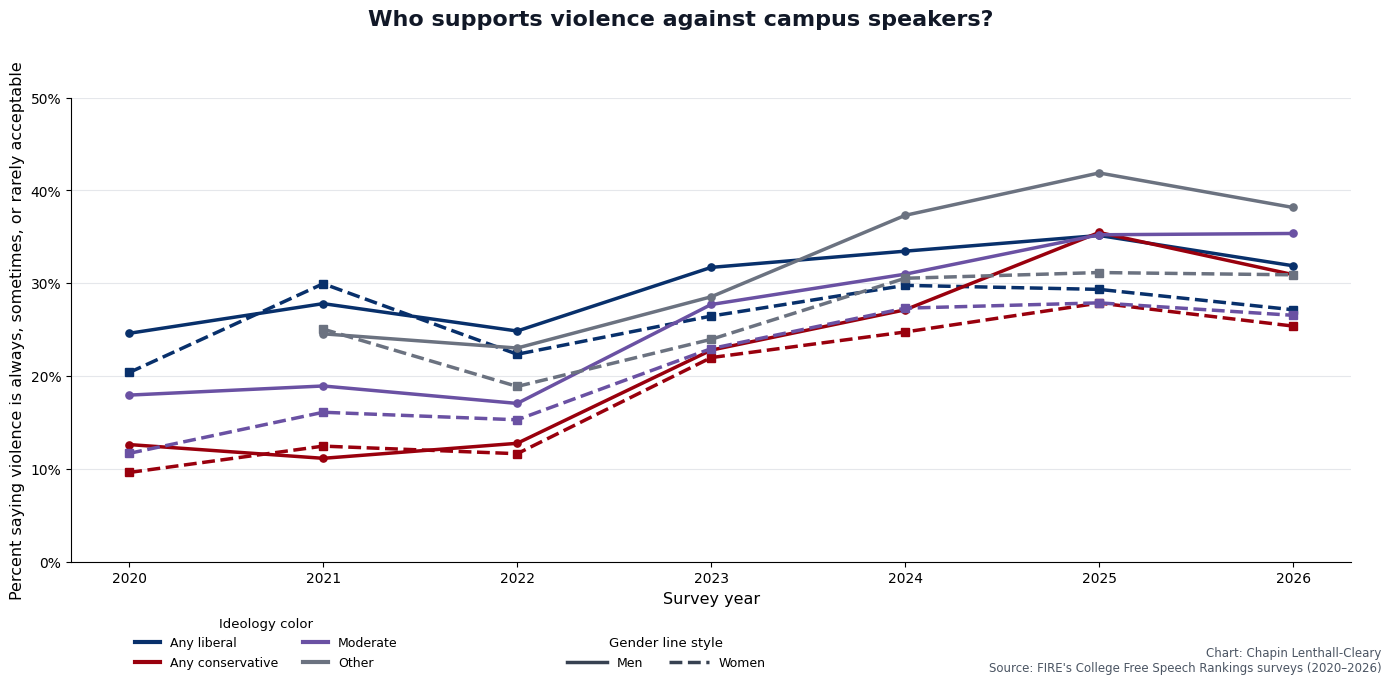

Saved: charts/violense_datapost_plots_2026/01_violence_by_binned_ideology_and_gender_2020_2026.png


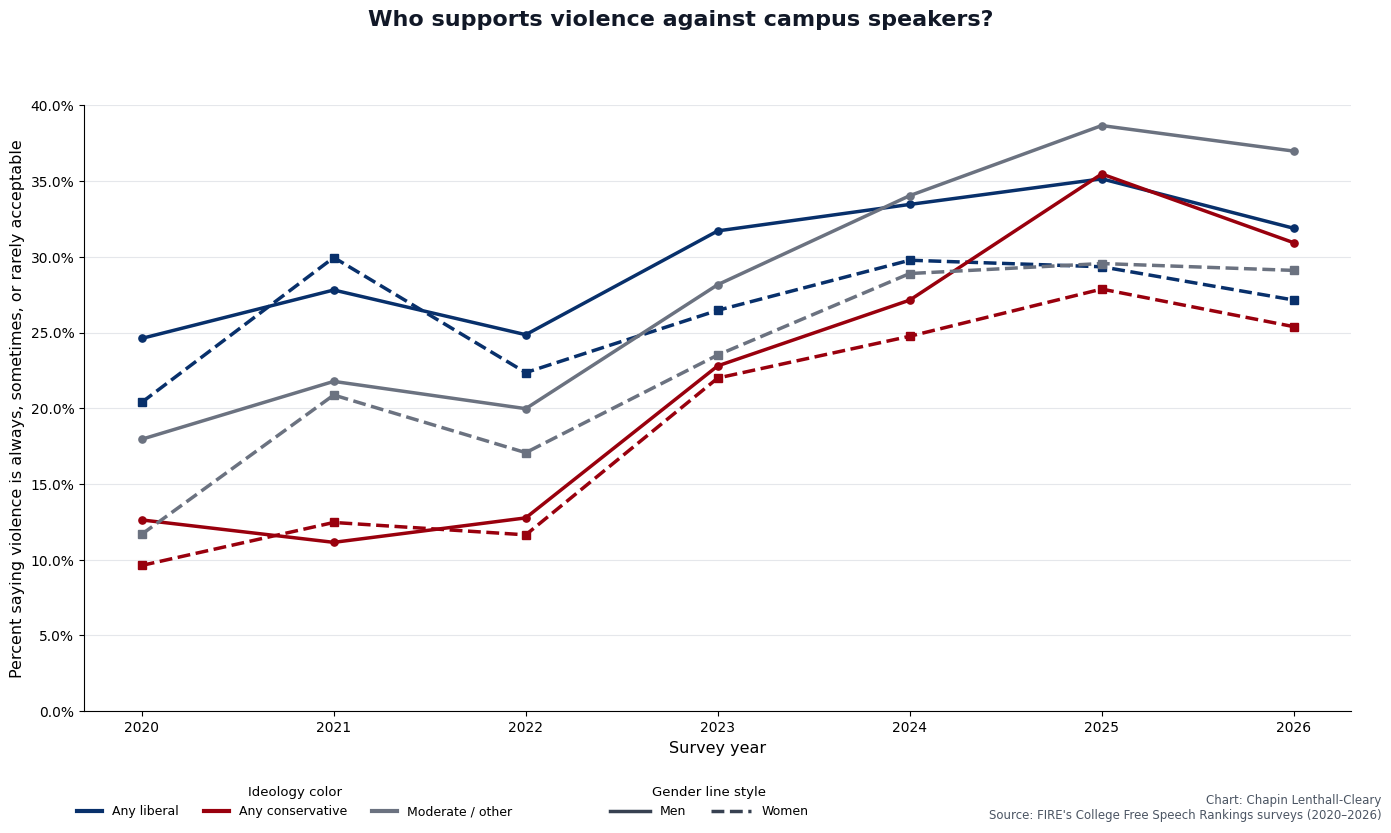

Saved: charts/violense_datapost_plots_2026/01b_violence_by_binned_ideology_and_gender_moderate_other_combined_2020_2026.png


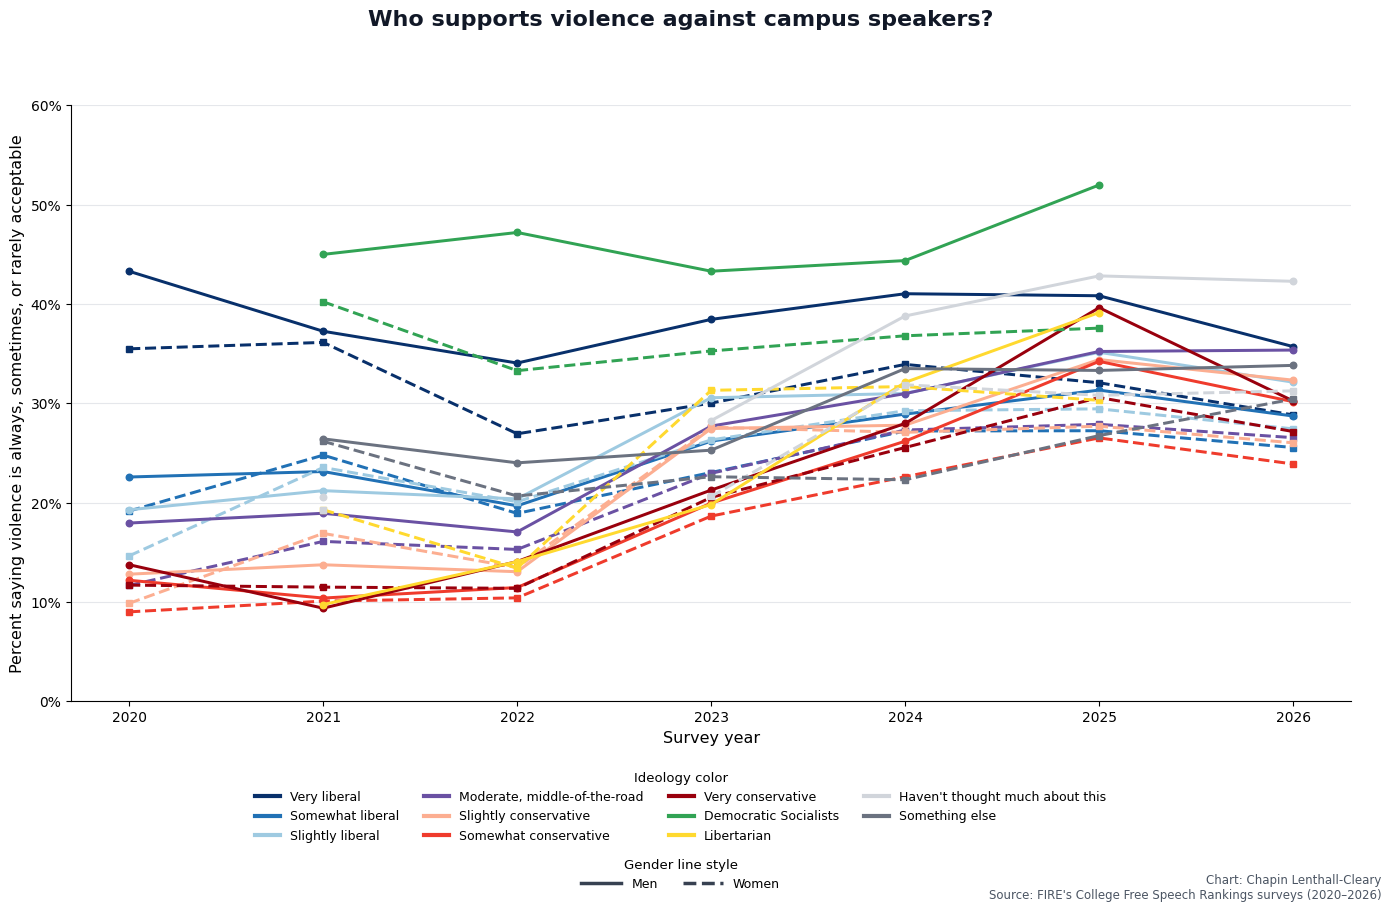

Saved: charts/violense_datapost_plots_2026/02_violence_by_all_ideologies_and_gender_2020_2026.png


PosixPath('charts/violense_datapost_plots_2026/02_violence_by_all_ideologies_and_gender_2020_2026.png')

In [3]:
years = list(range(2020, 2027))
binned_summary = summarize_percent(violence, [YEAR_COL, "ideo_bin", "gender_label"])
combined_bin_frame = violence.copy()
combined_bin_frame["combined_ideo_bin"] = combined_bin_frame["ideo_bin"].replace(
    {"Moderate": "Moderate / other", "Other": "Moderate / other"}
)
combined_bin_summary = summarize_percent(
    combined_bin_frame, [YEAR_COL, "combined_ideo_bin", "gender_label"]
)
COMBINED_BIN_ORDER = [
    "Any liberal",
    "Any conservative",
    "Moderate / other",
]
COMBINED_BIN_COLORS = {
    "Any liberal": IDEO_BIN_COLORS["Any liberal"],
    "Any conservative": IDEO_BIN_COLORS["Any conservative"],
    "Moderate / other": "#6b7280",
}
all_ideology_summary = summarize_percent(violence, [YEAR_COL, IDEO_COL, "gender_label"])


def add_line_chart_legends(
    fig,
    ideology_handles,
    gender_handles,
    *,
    ideology_columns,
    ideology_x,
    gender_x,
    y,
    gender_y=None,
):
    if gender_y is None:
        gender_y = y
    fig.legend(
        handles=ideology_handles,
        loc="lower center",
        bbox_to_anchor=(ideology_x, y),
        ncol=ideology_columns,
        frameon=False,
        title="Ideology color",
        title_fontsize=9.5,
    )
    fig.legend(
        handles=gender_handles,
        loc="lower center",
        bbox_to_anchor=(gender_x, gender_y),
        ncol=2,
        frameon=False,
        title="Gender line style",
        title_fontsize=9.5,
        handlelength=3.2,
    )


def plot_binned_ideology_gender():
    fig, ax = plt.subplots(figsize=(14.3, 7.8))
    y_max = rounded_ymax(binned_summary["pct_at_least_rarely"])
    for bin_label in IDEO_BIN_ORDER:
        for gender_label in ["Men", "Women"]:
            group = binned_summary[
                binned_summary["ideo_bin"].eq(bin_label)
                & binned_summary["gender_label"].eq(gender_label)
            ]
            series = group.set_index(YEAR_COL).reindex(years)["pct_at_least_rarely"]
            ax.plot(
                years,
                series,
                color=IDEO_BIN_COLORS[bin_label],
                linestyle=GENDER_LINESTYLES[gender_label],
                marker=GENDER_MARKERS[gender_label],
                linewidth=2.5,
                markersize=5.2,
            )

    style_percent_axis(ax, years, "", y_max)
    ideology_handles = [
        Line2D([0], [0], color=IDEO_BIN_COLORS[label], linewidth=3, label=label)
        for label in IDEO_BIN_ORDER
    ]
    gender_handles = [
        Line2D(
            [0], [0], color="#374151", linestyle=GENDER_LINESTYLES[label],
            linewidth=2.5, label=label,
        )
        for label in ["Men", "Women"]
    ]
    add_line_chart_legends(
        fig,
        ideology_handles,
        gender_handles,
        ideology_columns=2,
        ideology_x=0.21,
        gender_x=0.49,
        y=0.105,
    )
    add_figure_heading(
        fig,
        "Who supports violence against campus speakers?",
    )
    add_credit(fig, LONGITUDINAL_SOURCE, y=0.113)
    fig.tight_layout(rect=[0.02, 0.18, 0.98, 0.925])
    return save_and_show(fig, "01_violence_by_binned_ideology_and_gender_2020_2026.png")


def plot_binned_ideology_gender_moderate_other_combined():
    fig, ax = plt.subplots(figsize=(14.3, 9.7))
    y_max = 40
    for bin_label in COMBINED_BIN_ORDER:
        for gender_label in ["Men", "Women"]:
            group = combined_bin_summary[
                combined_bin_summary["combined_ideo_bin"].eq(bin_label)
                & combined_bin_summary["gender_label"].eq(gender_label)
            ]
            series = group.set_index(YEAR_COL).reindex(years)["pct_at_least_rarely"]
            ax.plot(
                years,
                series,
                color=COMBINED_BIN_COLORS[bin_label],
                linestyle=GENDER_LINESTYLES[gender_label],
                marker=GENDER_MARKERS[gender_label],
                linewidth=2.5,
                markersize=5.2,
            )

    style_percent_axis(ax, years, "", y_max)
    ideology_handles = [
        Line2D([0], [0], color=COMBINED_BIN_COLORS[label], linewidth=3, label=label)
        for label in COMBINED_BIN_ORDER
    ]
    gender_handles = [
        Line2D(
            [0], [0], color="#374151", linestyle=GENDER_LINESTYLES[label],
            linewidth=2.5, label=label,
        )
        for label in ["Men", "Women"]
    ]
    add_line_chart_legends(
        fig,
        ideology_handles,
        gender_handles,
        ideology_columns=3,
        ideology_x=0.23,
        gender_x=0.52,
        y=0.120,
    )
    add_figure_heading(
        fig,
        "Who supports violence against campus speakers?",
    )
    add_credit(fig, LONGITUDINAL_SOURCE, y=0.128)
    fig.tight_layout(rect=[0.02, 0.18, 0.98, 0.925])
    return save_and_show(
        fig,
        "01b_violence_by_binned_ideology_and_gender_moderate_other_combined_2020_2026.png",
    )


def plot_all_ideologies_gender():
    fig, ax = plt.subplots(figsize=(14.3, 9.7))
    y_max = rounded_ymax(all_ideology_summary["pct_at_least_rarely"])
    for ideology in IDEO_ORDER:
        for gender_label in ["Men", "Women"]:
            group = all_ideology_summary[
                all_ideology_summary[IDEO_COL].eq(ideology)
                & all_ideology_summary["gender_label"].eq(gender_label)
            ]
            series = group.set_index(YEAR_COL).reindex(years)["pct_at_least_rarely"]
            ax.plot(
                years,
                series,
                color=IDEO_COLORS[ideology],
                linestyle=GENDER_LINESTYLES[gender_label],
                marker=GENDER_MARKERS[gender_label],
                linewidth=2.15,
                markersize=4.7,
            )

    style_percent_axis(ax, years, "", y_max)
    ideology_handles = [
        Line2D([0], [0], color=IDEO_COLORS[code], linewidth=3, label=IDEO_LABELS[code])
        for code in IDEO_ORDER
    ]
    gender_handles = [
        Line2D(
            [0], [0], color="#374151", linestyle=GENDER_LINESTYLES[label],
            linewidth=2.5, label=label,
        )
        for label in ["Men", "Women"]
    ]
    add_line_chart_legends(
        fig,
        ideology_handles,
        gender_handles,
        ideology_columns=4,
        ideology_x=0.50,
        gender_x=0.50,
        y=0.095,
        gender_y=0.045,
    )
    add_figure_heading(
        fig,
        "Who supports violence against campus speakers?",
    )
    add_credit(fig, LONGITUDINAL_SOURCE, y=0.045)
    fig.tight_layout(rect=[0.02, 0.19, 0.98, 0.925])
    return save_and_show(fig, "02_violence_by_all_ideologies_and_gender_2020_2026.png")


plot_binned_ideology_gender()
plot_binned_ideology_gender_moderate_other_combined()
plot_all_ideologies_gender()

## 3–4. The changing gender/ideology relationship, 2020–2026

Weighted versions are shown first, followed by matching unweighted versions. Raw correlations begin in 2020; standardized within-year multivariable regressions of the 1–4 violence-support scale on linear ideology and a male indicator begin in 2021.


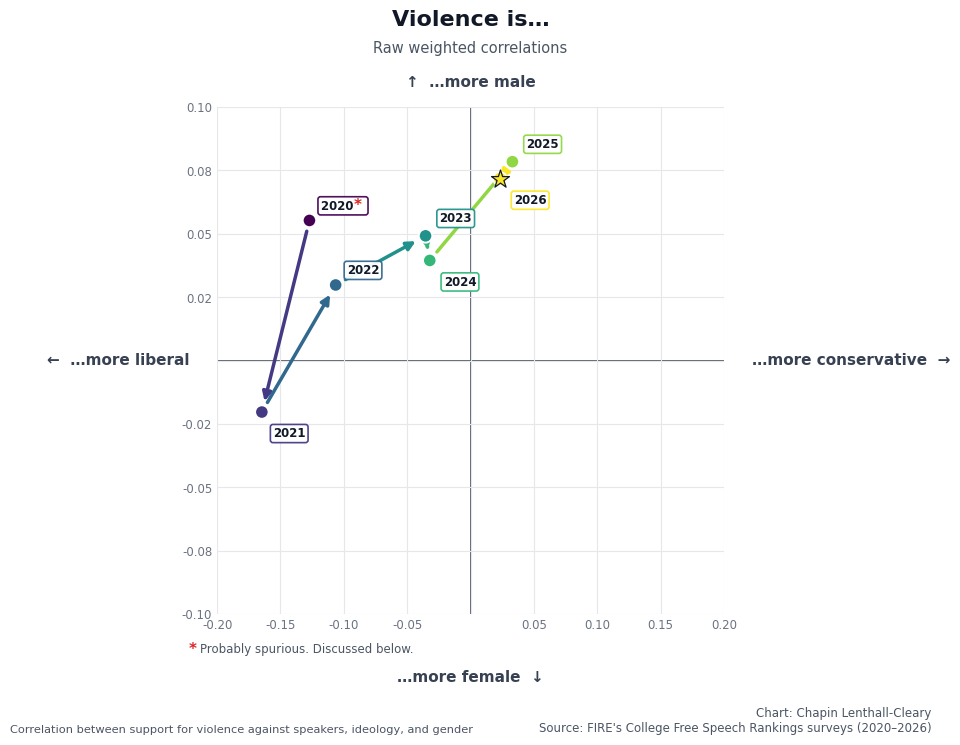

Saved: charts/violense_datapost_plots_2026/03_violence_raw_correlations_gender_ideology_2020_2026.png


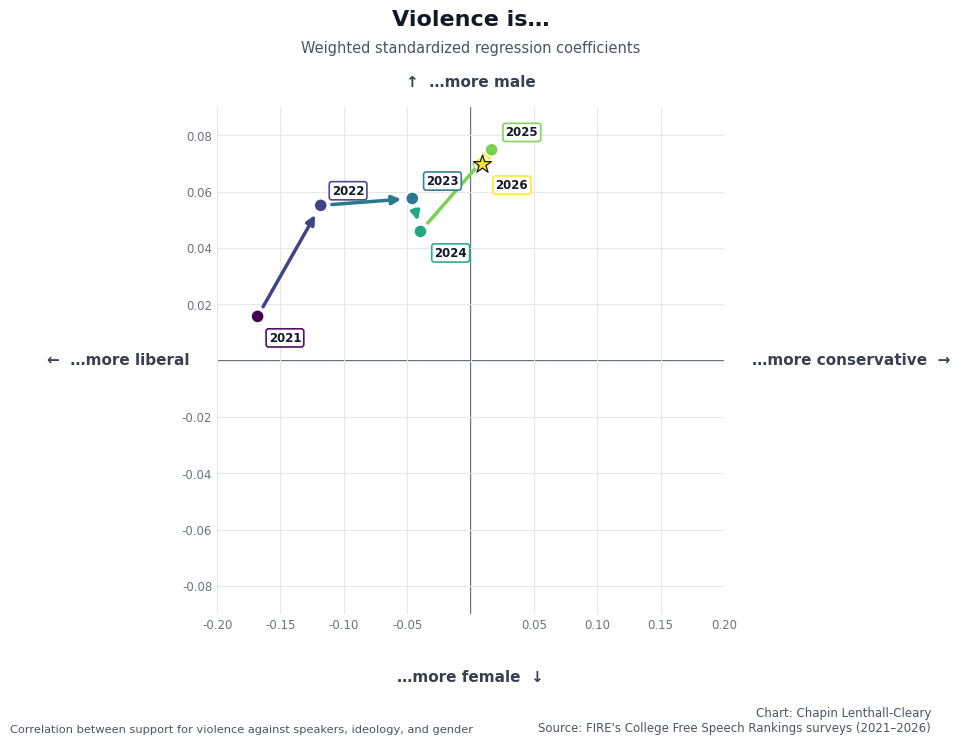

Saved: charts/violense_datapost_plots_2026/04_violence_multivariable_regression_gender_ideology_2020_2026.png


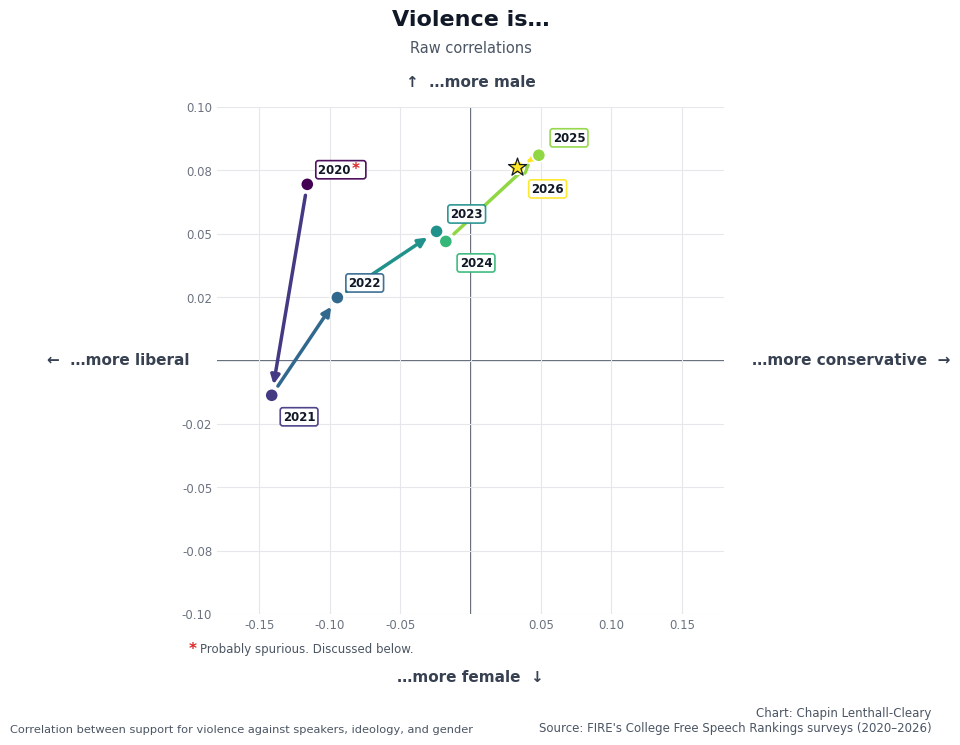

Saved: charts/violense_datapost_plots_2026/03b_violence_raw_correlations_gender_ideology_unweighted_2020_2026.png


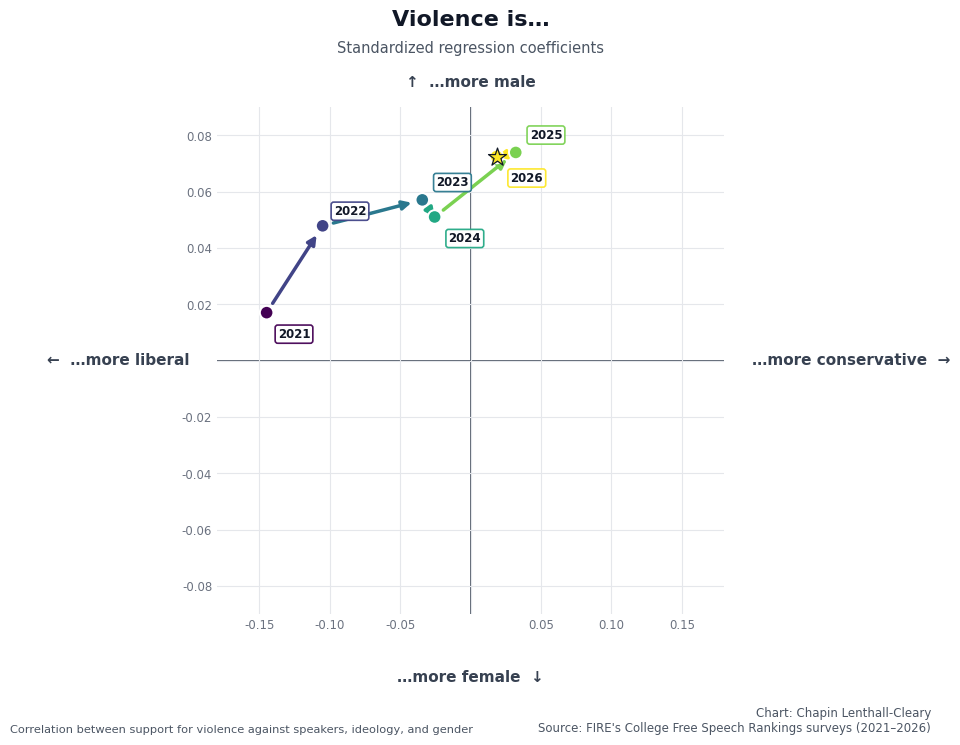

Saved: charts/violense_datapost_plots_2026/04b_violence_multivariable_regression_gender_ideology_unweighted_2020_2026.png


PosixPath('charts/violense_datapost_plots_2026/04b_violence_multivariable_regression_gender_ideology_unweighted_2020_2026.png')

In [4]:
def weighted_corr(x, y, weights):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)
    weights = pd.Series(weights, dtype=float)
    valid = x.notna() & y.notna() & weights.notna() & weights.gt(0)
    x, y, weights = x[valid], y[valid], weights[valid]
    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)
    covariance = np.average((x - x_mean) * (y - y_mean), weights=weights)
    x_variance = np.average((x - x_mean) ** 2, weights=weights)
    y_variance = np.average((y - y_mean) ** 2, weights=weights)
    return covariance / np.sqrt(x_variance * y_variance)


def weighted_standardized_regression(y, predictors, weights):
    model = predictors.copy()
    model["_y"] = y
    model["_weight"] = weights
    model = model.dropna()
    model = model[model["_weight"].gt(0)]
    standardized = pd.DataFrame(index=model.index)
    for column in ["_y", *predictors.columns]:
        values = model[column].astype(float)
        mean = np.average(values, weights=model["_weight"])
        variance = np.average((values - mean) ** 2, weights=model["_weight"])
        standardized[column] = (values - mean) / np.sqrt(variance)
    design = np.column_stack([
        np.ones(len(standardized)), standardized[predictors.columns].to_numpy(dtype=float)
    ])
    outcome = standardized["_y"].to_numpy(dtype=float)
    sqrt_weight = np.sqrt(model["_weight"].to_numpy(dtype=float))
    coefficients = np.linalg.lstsq(
        design * sqrt_weight[:, None], outcome * sqrt_weight, rcond=None
    )[0]
    return dict(zip(predictors.columns, coefficients[1:]))


linear = violence[violence[IDEO_COL].isin(range(1, 8))].copy()
trajectory_rows = []
unweighted_trajectory_rows = []
for year, group in linear.groupby(YEAR_COL, sort=True):
    predictors = group[[IDEO_COL, "male_indicator"]].astype(float).rename(
        columns={IDEO_COL: "ideology_1_to_7"}
    )
    coefficients = weighted_standardized_regression(
        group["violence_support"], predictors, group["clean_weight"]
    )
    trajectory_rows.append({
        YEAR_COL: int(year),
        "ideology_correlation": weighted_corr(
            group[IDEO_COL], group["violence_support"], group["clean_weight"]
        ),
        "gender_correlation": weighted_corr(
            group["male_indicator"], group["violence_support"], group["clean_weight"]
        ),
        "ideology_beta": coefficients["ideology_1_to_7"],
        "gender_beta": coefficients["male_indicator"],
    })
    equal_weights = pd.Series(1.0, index=group.index)
    unweighted_coefficients = weighted_standardized_regression(
        group["violence_support"], predictors, equal_weights
    )
    unweighted_trajectory_rows.append({
        YEAR_COL: int(year),
        "ideology_correlation": weighted_corr(
            group[IDEO_COL], group["violence_support"], equal_weights
        ),
        "gender_correlation": weighted_corr(
            group["male_indicator"], group["violence_support"], equal_weights
        ),
        "ideology_beta": unweighted_coefficients["ideology_1_to_7"],
        "gender_beta": unweighted_coefficients["male_indicator"],
    })
trajectory = pd.DataFrame(trajectory_rows)
unweighted_trajectory = pd.DataFrame(unweighted_trajectory_rows)


def symmetric_axis_limit(values, minimum=0.05):
    values = pd.Series(values, dtype=float).dropna()
    magnitude = max(abs(values.min()), abs(values.max())) * 1.18
    step = 0.02 if magnitude >= 0.10 else 0.01
    return max(minimum, np.ceil(magnitude / step) * step)


def add_directional_labels(ax):
    style = dict(fontsize=11, fontweight="semibold", color="#374151", clip_on=False)
    ax.text(-0.055, 0.50, "←  …more liberal", transform=ax.transAxes,
            ha="right", va="center", **style)
    ax.text(1.055, 0.50, "…more conservative  →", transform=ax.transAxes,
            ha="left", va="center", **style)
    ax.text(0.50, 1.035, "↑  …more male", transform=ax.transAxes,
            ha="center", va="bottom", **style)
    ax.text(0.50, -0.11, "…more female  ↓", transform=ax.transAxes,
            ha="center", va="top", **style)


def plot_progressional_trajectory(
    x_col, y_col, method_label, filename, note, start_year=2020, trajectory_data=None,
):
    if trajectory_data is None:
        trajectory_data = trajectory
    plot_data = (
        trajectory_data[trajectory_data[YEAR_COL].ge(start_year)]
        .sort_values(YEAR_COL)
        .reset_index(drop=True)
    )
    first_year = int(plot_data[YEAR_COL].min())
    last_year = int(plot_data[YEAR_COL].max())
    norm = Normalize(vmin=first_year, vmax=last_year)
    cmap = plt.colormaps["viridis"]
    fig, ax = plt.subplots(figsize=(9.4, 7.8))
    for position in range(len(plot_data) - 1):
        start = plot_data.iloc[position]
        end = plot_data.iloc[position + 1]
        ax.annotate(
            "", xy=(end[x_col], end[y_col]), xytext=(start[x_col], start[y_col]),
            arrowprops=dict(arrowstyle="-|>", color=cmap(norm(int(end[YEAR_COL]))),
                            lw=2.5, mutation_scale=13, shrinkA=8, shrinkB=8),
            zorder=2,
        )
    colors = [cmap(norm(int(year))) for year in plot_data[YEAR_COL]]
    ax.scatter(plot_data[x_col], plot_data[y_col], s=95, c=colors,
               edgecolor="white", linewidth=1.4, zorder=4)
    latest = plot_data.iloc[-1]
    ax.scatter(latest[x_col], latest[y_col], s=185, marker="*",
               color=cmap(norm(last_year)), edgecolor="#111827", linewidth=0.9, zorder=5)
    offsets = {
        2020: (8, 8), 2021: (8, -18), 2022: (8, 8),
        2023: (10, 10), 2024: (10, -18), 2025: (10, 10), 2026: (10, -18),
    }
    for row in plot_data.itertuples(index=False):
        year = int(getattr(row, YEAR_COL))
        ax.annotate(
            ("2020   " if year == 2020 else str(year)),
            (getattr(row, x_col), getattr(row, y_col)),
            xytext=offsets[year], textcoords="offset points", fontsize=8.5,
            fontweight="semibold", color="#111827",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                      edgecolor=cmap(norm(year)), linewidth=1.2, alpha=0.94),
            zorder=6,
        )
        if year == 2020:
            ax.annotate(
                "*", (getattr(row, x_col), getattr(row, y_col)),
                xytext=(offsets[year][0] + 24, offsets[year][1]),
                textcoords="offset points", fontsize=11, fontweight="bold",
                color="#dc2626", zorder=7,
            )
    ax.set_xlim(-symmetric_axis_limit(plot_data[x_col]), symmetric_axis_limit(plot_data[x_col]))
    ax.set_ylim(-symmetric_axis_limit(plot_data[y_col]), symmetric_axis_limit(plot_data[y_col]))
    ax.axhline(0, color="#4b5563", linewidth=1.25, zorder=1)
    ax.axvline(0, color="#4b5563", linewidth=1.25, zorder=1)
    ax.grid(color=STYLE_GRID, linewidth=0.8, zorder=0)
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    hide_origin = FuncFormatter(lambda value, _: "" if np.isclose(value, 0) else f"{value:.2f}")
    ax.xaxis.set_major_formatter(hide_origin)
    ax.yaxis.set_major_formatter(hide_origin)
    ax.tick_params(axis="both", colors="#6b7280", labelsize=8.5, length=0)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_box_aspect(1)
    add_directional_labels(ax)
    add_figure_heading(
        fig,
        "Violence is…",
        method_label,
        title_y=0.965,
        subtitle_y=0.925,
    )
    add_note(
        fig,
        note,
        y=0.035,
    )
    add_credit(
        fig,
        f"Source: FIRE's College Free Speech Rankings surveys ({first_year}–{last_year})",
        y=0.035,
    )
    if first_year == 2020:
        fig.text(0.20, 0.145, "*", ha="left", va="center",
                 fontsize=11, fontweight="bold", color="#dc2626")
        fig.text(0.212, 0.145, "Probably spurious. Discussed below.",
                 ha="left", va="center", fontsize=8.5, color=STYLE_MUTED)
    fig.subplots_adjust(left=0.20, right=0.80, bottom=0.19, top=0.84)
    return save_and_show(fig, filename)


plot_progressional_trajectory(
    "ideology_correlation", "gender_correlation", "Raw weighted correlations",
    "03_violence_raw_correlations_gender_ideology_2020_2026.png",
    "Correlation between support for violence against speakers, ideology, and gender",
)
plot_progressional_trajectory(
    "ideology_beta", "gender_beta", "Weighted standardized regression coefficients",
    "04_violence_multivariable_regression_gender_ideology_2020_2026.png",
    "Correlation between support for violence against speakers, ideology, and gender",
    start_year=2021,
)
plot_progressional_trajectory(
    "ideology_correlation", "gender_correlation", "Raw correlations",
    "03b_violence_raw_correlations_gender_ideology_unweighted_2020_2026.png",
    "Correlation between support for violence against speakers, ideology, and gender",
    trajectory_data=unweighted_trajectory,
)
plot_progressional_trajectory(
    "ideology_beta", "gender_beta", "Standardized regression coefficients",
    "04b_violence_multivariable_regression_gender_ideology_unweighted_2020_2026.png",
    "Correlation between support for violence against speakers, ideology, and gender",
    start_year=2021,
    trajectory_data=unweighted_trajectory,
)

## 5. Violence support by average speaker tolerance, 2026

This is the compact two-line article version updated to the 2026 respondent data and the six 2026 speaker questions.


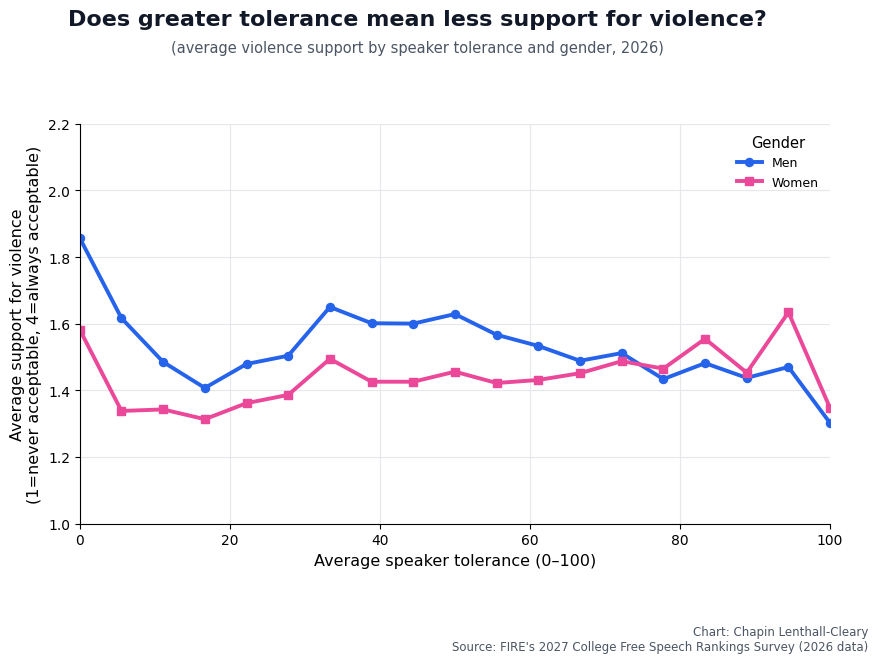

Saved: charts/violense_datapost_plots_2026/05_violence_by_average_tolerance_gender_2026.png


PosixPath('charts/violense_datapost_plots_2026/05_violence_by_average_tolerance_gender_2026.png')

In [5]:
points_2026 = (
    tolerance_data[tolerance_data[YEAR_COL].eq(2026)]
    .groupby(["heatmap_gender", "average_tolerance"])["violence_support"]
    .mean()
    .rename("average_violence_support")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9.2, 6.8))
for gender_code, gender_label in GENDER_LABELS.items():
    line = points_2026[
        points_2026["heatmap_gender"].eq(gender_code)
    ].sort_values("average_tolerance")
    ax.plot(
        line["average_tolerance"],
        line["average_violence_support"],
        color=GENDER_COLORS[gender_label],
        marker=GENDER_MARKERS[gender_label],
        linewidth=2.8,
        markersize=5.8,
        label=gender_label,
    )

ax.set_xlabel("Average speaker tolerance (0–100)")
ax.set_ylabel("Average support for violence\n(1=never acceptable, 4=always acceptable)")
ax.set_xlim(0, 100)
ax.set_ylim(1.0, 2.2)
ax.set_xticks(np.arange(0, 101, 20))
ax.grid(color=STYLE_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", frameon=False, title="Gender")
add_figure_heading(
    fig,
    "Does greater tolerance mean less support for violence?",
    "(average violence support by speaker tolerance and gender, 2026)",
)
add_credit(fig, YEAR_2026_SOURCE)
fig.tight_layout(rect=[0.04, 0.12, 0.98, 0.88])
save_and_show(fig, "05_violence_by_average_tolerance_gender_2026.png")

## 6. Where men and women fall on the free-speech map, 2026

This recreates the article's contextual free-speech map using the 2026 respondent data and the six 2026 speaker questions.


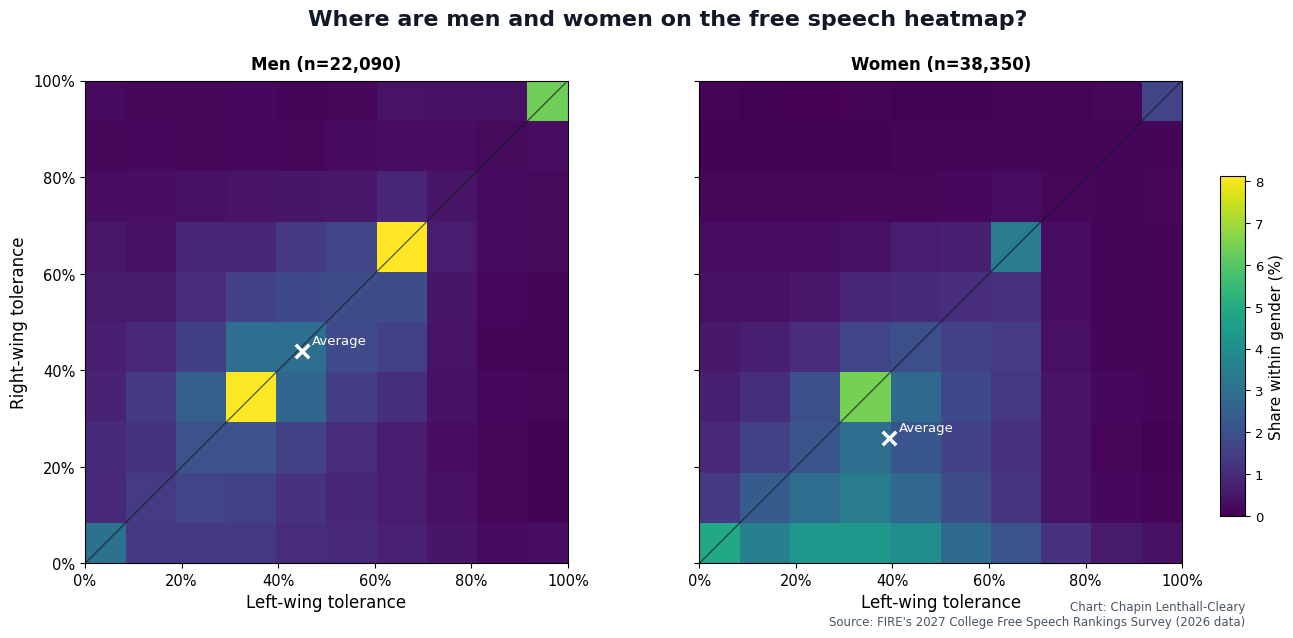

Saved: charts/violense_datapost_plots_2026/06_free_speech_map_by_gender_2026.png


PosixPath('charts/violense_datapost_plots_2026/06_free_speech_map_by_gender_2026.png')

In [6]:
year_2026 = tolerance_data[tolerance_data[YEAR_COL].eq(2026)].copy()
edges = np.linspace(-2, 102, 11)
grids = {}
cmax = 0.0
for gender_code in GENDER_LABELS:
    subset = year_2026[year_2026["heatmap_gender"].eq(gender_code)]
    counts, x_edges, y_edges = np.histogram2d(
        subset["left_tolerance"], subset["right_tolerance"], bins=[edges, edges]
    )
    percentages = counts / len(subset) * 100
    grids[gender_code] = (subset, percentages, x_edges, y_edges)
    cmax = max(cmax, percentages.max())

fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.8), sharex=True, sharey=True)
mesh = None
for ax, gender_code in zip(axes, GENDER_LABELS):
    subset, percentages, x_edges, y_edges = grids[gender_code]
    mesh = ax.pcolormesh(
        x_edges, y_edges, percentages.T, shading="auto", vmin=0, vmax=cmax
    )
    ax.set_title(
        f"{GENDER_LABELS[gender_code]} (n={len(subset):,})",
        fontsize=12,
        fontweight="semibold",
        pad=8,
    )
    ax.set_xlabel("Left-wing tolerance", fontsize=12)
    if gender_code == 1:
        ax.set_ylabel("Right-wing tolerance", fontsize=12)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_aspect("equal", adjustable="box")
    ax.plot([0, 100], [0, 100], color="#111827", linewidth=1, alpha=0.65)
    mean_left = subset["left_tolerance"].mean()
    mean_right = subset["right_tolerance"].mean()
    ax.scatter(
        [mean_left], [mean_right], marker="x", s=95,
        color="white", linewidths=2.5, zorder=3,
    )
    ax.annotate(
        "Average", (mean_left, mean_right), textcoords="offset points",
        xytext=(7, 5), color="white", fontsize=9.5,
    )
    ax.tick_params(labelsize=10.5)

fig.subplots_adjust(left=0.07, right=0.88, bottom=0.15, top=0.86, wspace=0.22)
cbar_ax = fig.add_axes([0.90, 0.22, 0.018, 0.50])
colorbar = fig.colorbar(mesh, cax=cbar_ax)
colorbar.set_label("Share within gender (%)", fontsize=11)
colorbar.ax.tick_params(labelsize=9.5)
add_figure_heading(
    fig,
    "Where are men and women on the free speech heatmap?",
)
add_credit(fig, YEAR_2026_SOURCE, x=0.918, y=0.055)
save_and_show(fig, "06_free_speech_map_by_gender_2026.png")

## 7–8. Violence across the free-speech map, 2026

The shared color scale is set from all populated 2026 cells. Red × marks cells with fewer than 100 respondents. The second version applies the article's neon-green region boxes to the 2026 map.


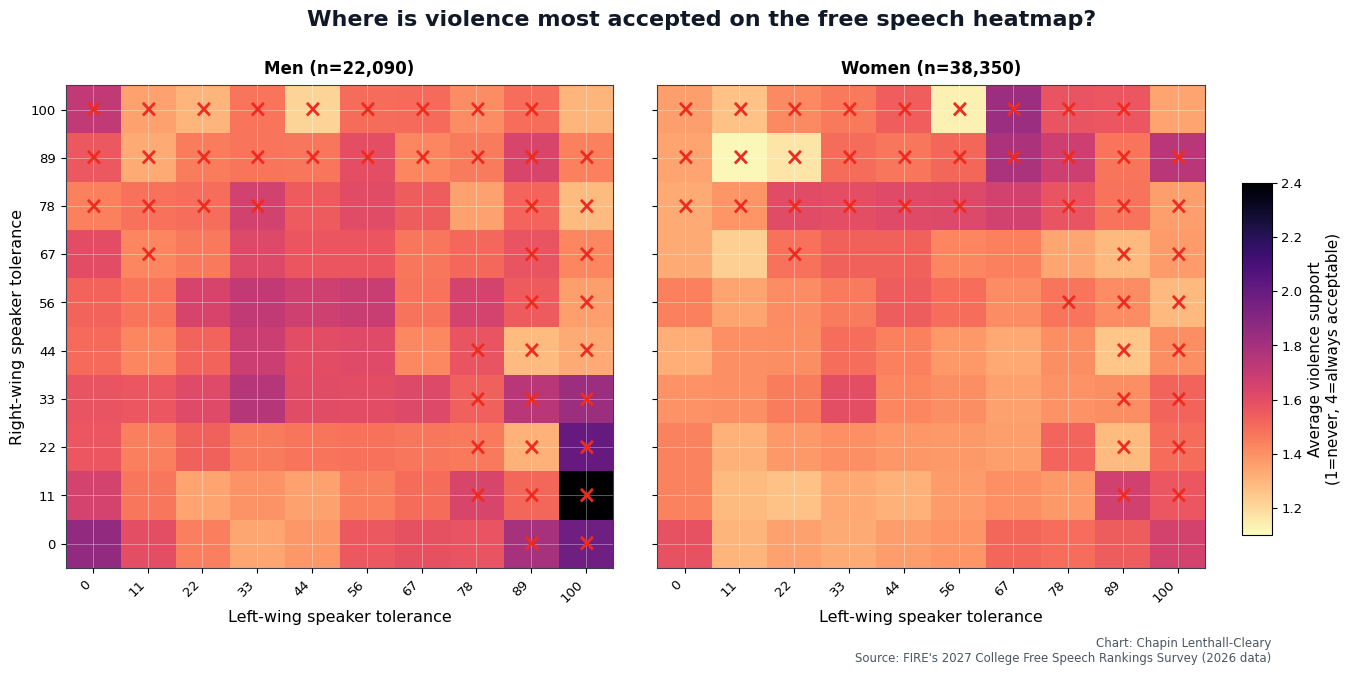

Saved: charts/violense_datapost_plots_2026/07_violence_free_speech_heatmaps_by_gender_2026.png


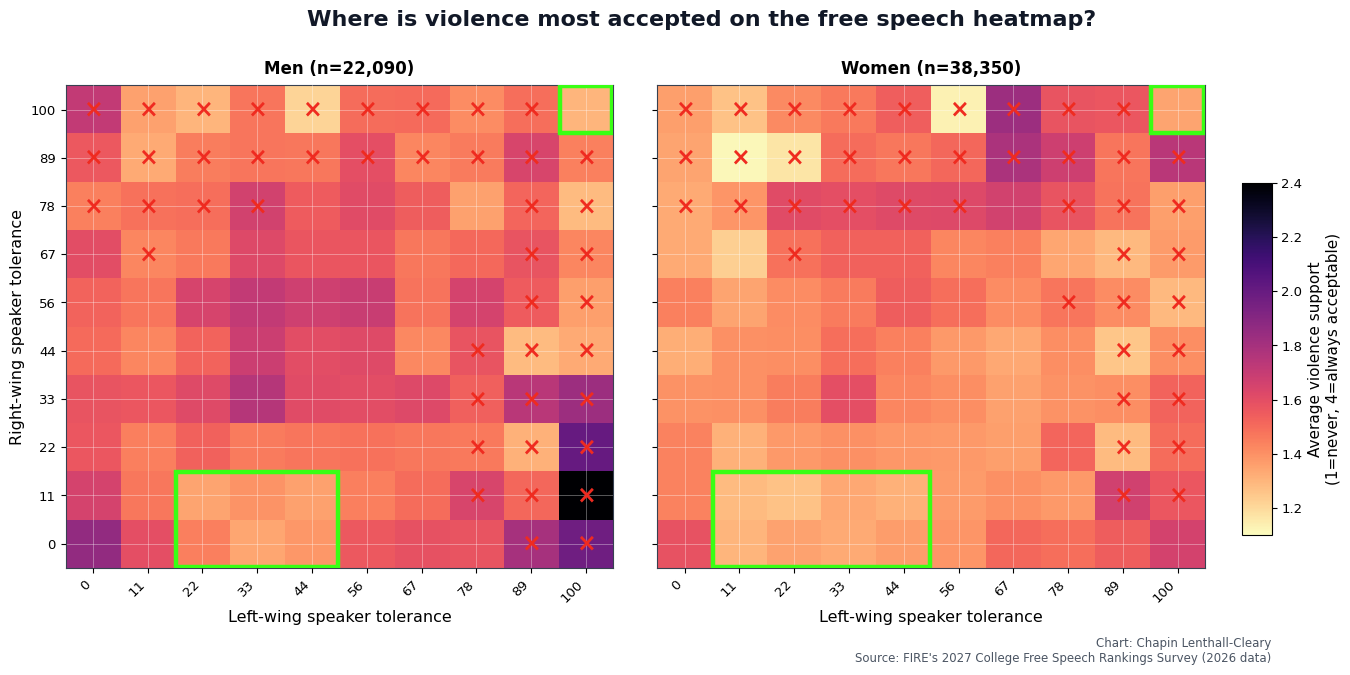

Saved: charts/violense_datapost_plots_2026/08_violence_free_speech_heatmaps_by_gender_2026_highlighted_regions.png


PosixPath('charts/violense_datapost_plots_2026/08_violence_free_speech_heatmaps_by_gender_2026_highlighted_regions.png')

In [7]:
def build_violence_cells(frame, year, gender_code):
    subset = frame[
        frame[YEAR_COL].eq(year) & frame["heatmap_gender"].eq(gender_code)
    ]
    return (
        subset.groupby(["left_tolerance", "right_tolerance"])
        .agg(avg_violence_support=("violence_support", "mean"), n=("violence_support", "size"))
        .reset_index()
    )


violence_cells_2026 = {
    gender_code: build_violence_cells(tolerance_data, 2026, gender_code)
    for gender_code in GENDER_LABELS
}
all_2026_cell_means = pd.concat(
    [table["avg_violence_support"] for table in violence_cells_2026.values()],
    ignore_index=True,
)
# This per-year, all-populated-cell scaling is the version embedded in the article.
VIOLENCE_VMIN = np.floor(all_2026_cell_means.min() * 10) / 10
VIOLENCE_VMAX = np.ceil(all_2026_cell_means.max() * 10) / 10
assert (VIOLENCE_VMIN, VIOLENCE_VMAX) == (1.1, 2.4)


def add_article_region_boxes(ax, gender_code, x_levels, y_levels):
    x_positions = {round(value): position for position, value in enumerate(x_levels)}
    y_positions = {round(value): position for position, value in enumerate(y_levels)}
    left_low, left_high = {1: (22, 44), 2: (11, 44)}[gender_code]
    middling_x = [position for value, position in x_positions.items() if left_low <= value <= left_high]
    low_right_y = [y_positions[value] for value in [0, 11] if value in y_positions]
    regions = [([x_positions[100]], [y_positions[100]]), (middling_x, low_right_y)]
    for region_x, region_y in regions:
        ax.add_patch(Rectangle(
            (min(region_x) - 0.48, min(region_y) - 0.48),
            max(region_x) - min(region_x) + 0.96,
            max(region_y) - min(region_y) + 0.96,
            fill=False, edgecolor="#39ff14", linewidth=3.2, zorder=7,
        ))


def add_men_perfect_intolerance_box(ax, gender_code, x_levels, y_levels):
    if gender_code != 1:
        return
    x_positions = {round(value): position for position, value in enumerate(x_levels)}
    y_positions = {round(value): position for position, value in enumerate(y_levels)}
    ax.add_patch(Rectangle(
        (x_positions[0] - 0.48, y_positions[0] - 0.48), 0.96, 0.96,
        fill=False, edgecolor="#39ff14", linewidth=3.2, zorder=7,
    ))


def plot_violence_heatmaps_2026(filename, highlight=None):
    year_data = tolerance_data[tolerance_data[YEAR_COL].eq(2026)]
    x_levels = sorted(year_data["left_tolerance"].unique())
    y_levels = sorted(year_data["right_tolerance"].unique())
    x_index = {value: position for position, value in enumerate(x_levels)}
    y_index = {value: position for position, value in enumerate(y_levels)}
    fig, axes = plt.subplots(1, 2, figsize=(14.8, 7.2), sharex=True, sharey=True)
    image = None

    for ax, gender_code in zip(axes, GENDER_LABELS):
        matrix = np.full((len(y_levels), len(x_levels)), np.nan)
        counts = np.zeros((len(y_levels), len(x_levels)), dtype=int)
        for row in violence_cells_2026[gender_code].itertuples(index=False):
            x_pos = x_index[row.left_tolerance]
            y_pos = y_index[row.right_tolerance]
            matrix[y_pos, x_pos] = row.avg_violence_support
            counts[y_pos, x_pos] = int(row.n)

        image = ax.imshow(
            matrix,
            origin="lower",
            cmap="magma_r",
            vmin=VIOLENCE_VMIN,
            vmax=VIOLENCE_VMAX,
            aspect="auto",
        )
        for y_pos in range(len(y_levels)):
            for x_pos in range(len(x_levels)):
                if 0 < counts[y_pos, x_pos] < MIN_HEATMAP_CELL_N:
                    ax.text(
                        x_pos, y_pos, "×", color="#ef2b20",
                        ha="center", va="center", fontsize=17, fontweight="bold",
                    )

        if highlight == "article_regions":
            add_article_region_boxes(ax, gender_code, x_levels, y_levels)
        elif highlight == "men_perfect_intolerance":
            add_men_perfect_intolerance_box(ax, gender_code, x_levels, y_levels)

        gender_n = int((year_data["heatmap_gender"] == gender_code).sum())
        ax.set_title(
            f"{GENDER_LABELS[gender_code]} (n={gender_n:,})",
            fontsize=12,
            fontweight="semibold",
            pad=8,
        )
        ax.set_xlabel("Left-wing speaker tolerance", fontsize=11.5)
        ax.set_xticks(range(len(x_levels)))
        ax.set_xticklabels(
            [f"{value:.0f}" for value in x_levels], rotation=45, ha="right"
        )
        ax.set_yticks(range(len(y_levels)))
        ax.set_yticklabels([f"{value:.0f}" for value in y_levels])
        ax.tick_params(labelsize=9.5)
        ax.grid(color="white", linewidth=0.6, alpha=0.40)
        ax.set_axisbelow(False)
        for spine in ax.spines.values():
            spine.set_color("#374151")
            spine.set_linewidth(0.8)

    axes[0].set_ylabel("Right-wing speaker tolerance", fontsize=11.5)
    fig.subplots_adjust(left=0.07, right=0.84, bottom=0.19, top=0.86, wspace=0.08)
    cbar_ax = fig.add_axes([0.865, 0.235, 0.020, 0.49])
    colorbar = fig.colorbar(image, cax=cbar_ax)
    colorbar.set_label(
        "Average violence support\n(1=never, 4=always acceptable)",
        fontsize=11,
    )
    colorbar.ax.tick_params(labelsize=9.5)

    add_figure_heading(
        fig,
        "Where is violence most accepted on the free speech heatmap?",
    )
    add_credit(fig, YEAR_2026_SOURCE, x=0.885, y=0.055)
    return save_and_show(fig, filename)


plot_violence_heatmaps_2026("07_violence_free_speech_heatmaps_by_gender_2026.png")
plot_violence_heatmaps_2026(
    "08_violence_free_speech_heatmaps_by_gender_2026_highlighted_regions.png",
    highlight="article_regions",
)

## 9. Voter registration across the free-speech map, 2026

The color direction is reversed from the violence map: brighter cells have higher voter-registration rates. The shared scale is set from cells with n ≥ 100 across 2021–2026. The megafile's harmonized 1/0 responses are converted to one binary indicator.


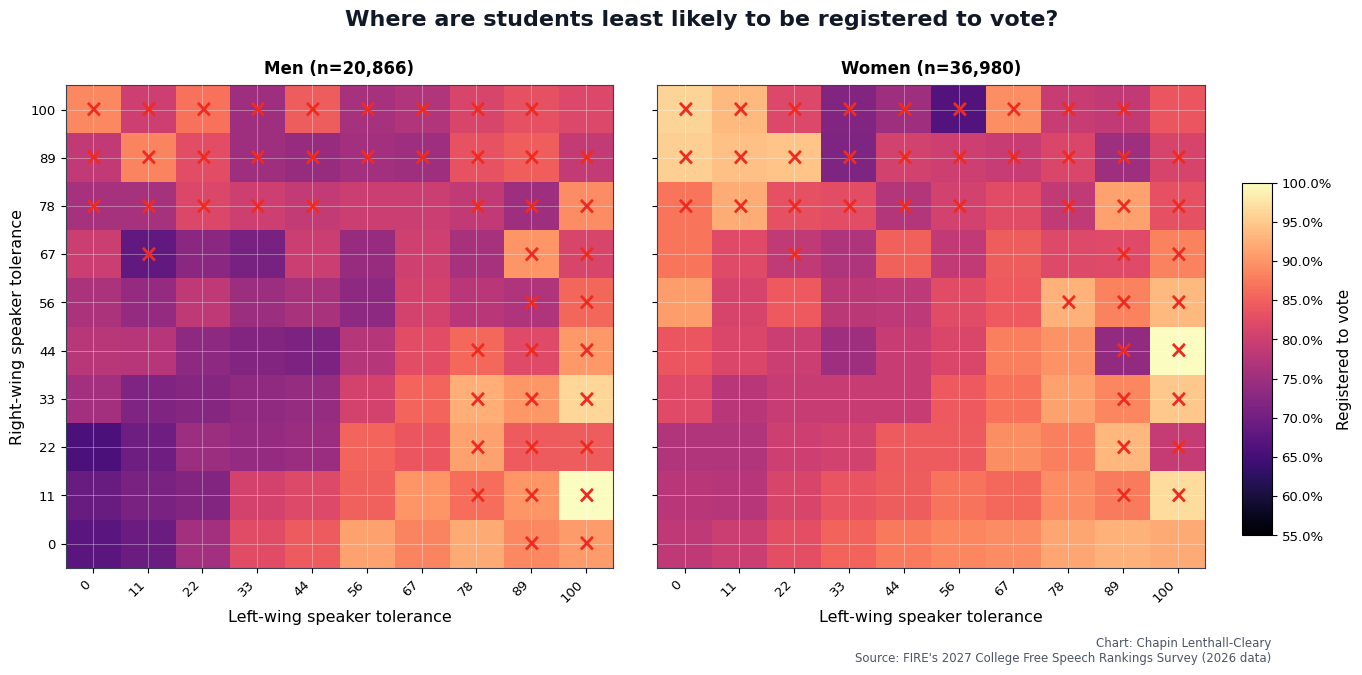

Saved: charts/violense_datapost_plots_2026/09_voter_registration_free_speech_heatmaps_by_gender_2026.png


PosixPath('charts/violense_datapost_plots_2026/09_voter_registration_free_speech_heatmaps_by_gender_2026.png')

In [8]:
def build_registration_cells(frame, year, gender_code):
    subset = frame[
        frame[YEAR_COL].eq(year) & frame["heatmap_gender"].eq(gender_code)
    ]
    return (
        subset.groupby(["left_tolerance", "right_tolerance"])
        .agg(
            percent_registered=("registered_to_vote", "mean"),
            n=("registered_to_vote", "size"),
        )
        .reset_index()
        .assign(percent_registered=lambda table: 100 * table["percent_registered"])
    )


all_registration_cells = {
    (year, gender_code): build_registration_cells(registration_data, year, gender_code)
    for year in TOLERANCE_YEARS
    for gender_code in GENDER_LABELS
}
reliable_registration = pd.concat(
    [
        table.loc[table["n"].ge(MIN_HEATMAP_CELL_N), "percent_registered"]
        for table in all_registration_cells.values()
    ],
    ignore_index=True,
)
REGISTRATION_VMIN = np.floor(reliable_registration.min() / 5) * 5
REGISTRATION_VMAX = np.ceil(reliable_registration.max() / 5) * 5
assert (REGISTRATION_VMIN, REGISTRATION_VMAX) == (55.0, 100.0)

year_data = registration_data[registration_data[YEAR_COL].eq(2026)]
x_levels = sorted(year_data["left_tolerance"].unique())
y_levels = sorted(year_data["right_tolerance"].unique())
x_index = {value: position for position, value in enumerate(x_levels)}
y_index = {value: position for position, value in enumerate(y_levels)}
fig, axes = plt.subplots(1, 2, figsize=(14.8, 7.2), sharex=True, sharey=True)
image = None

for ax, gender_code in zip(axes, GENDER_LABELS):
    table = all_registration_cells[(2026, gender_code)]
    matrix = np.full((len(y_levels), len(x_levels)), np.nan)
    counts = np.zeros((len(y_levels), len(x_levels)), dtype=int)
    for row in table.itertuples(index=False):
        x_pos = x_index[row.left_tolerance]
        y_pos = y_index[row.right_tolerance]
        matrix[y_pos, x_pos] = row.percent_registered
        counts[y_pos, x_pos] = int(row.n)

    image = ax.imshow(
        matrix,
        origin="lower",
        cmap="magma",
        vmin=REGISTRATION_VMIN,
        vmax=REGISTRATION_VMAX,
        aspect="auto",
    )
    for y_pos in range(len(y_levels)):
        for x_pos in range(len(x_levels)):
            if 0 < counts[y_pos, x_pos] < MIN_HEATMAP_CELL_N:
                ax.text(
                    x_pos, y_pos, "×", color="#ef2b20",
                    ha="center", va="center", fontsize=17, fontweight="bold",
                )

    gender_n = int((year_data["heatmap_gender"] == gender_code).sum())
    ax.set_title(
        f"{GENDER_LABELS[gender_code]} (n={gender_n:,})",
        fontsize=12,
        fontweight="semibold",
        pad=8,
    )
    ax.set_xlabel("Left-wing speaker tolerance", fontsize=11.5)
    ax.set_xticks(range(len(x_levels)))
    ax.set_xticklabels([f"{value:.0f}" for value in x_levels], rotation=45, ha="right")
    ax.set_yticks(range(len(y_levels)))
    ax.set_yticklabels([f"{value:.0f}" for value in y_levels])
    ax.tick_params(labelsize=9.5)
    ax.grid(color="white", linewidth=0.6, alpha=0.40)
    ax.set_axisbelow(False)
    for spine in ax.spines.values():
        spine.set_color("#374151")
        spine.set_linewidth(0.8)

axes[0].set_ylabel("Right-wing speaker tolerance", fontsize=11.5)
fig.subplots_adjust(left=0.07, right=0.84, bottom=0.19, top=0.86, wspace=0.08)
cbar_ax = fig.add_axes([0.865, 0.235, 0.020, 0.49])
colorbar = fig.colorbar(image, cax=cbar_ax)
colorbar.set_label("Registered to vote", fontsize=11)
colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
colorbar.ax.tick_params(labelsize=9.5)
add_figure_heading(
    fig,
    "Where are students least likely to be registered to vote?",
)
add_credit(fig, YEAR_2026_SOURCE, x=0.885, y=0.055)
save_and_show(fig, "09_voter_registration_free_speech_heatmaps_by_gender_2026.png")

## 10. Men's perfect-intolerance cell highlighted

This is the final article figure updated to 2026: the same violence map, with only the men's perfect-intolerance cell boxed in neon green.


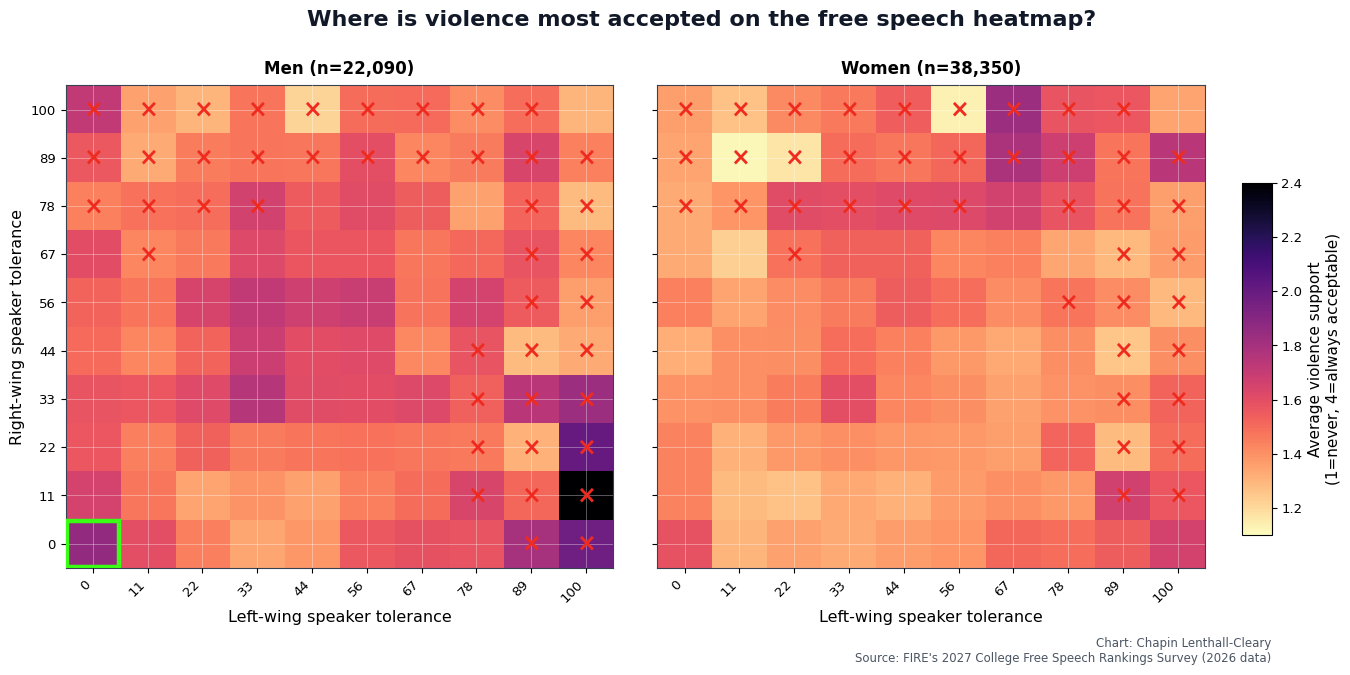

Saved: charts/violense_datapost_plots_2026/10_violence_free_speech_heatmaps_by_gender_2026_men_perfect_intolerance.png

Created the complete 2026 update, including weighted and unweighted correlation variants:
- charts/violense_datapost_plots_2026/01_violence_by_binned_ideology_and_gender_2020_2026.png
- charts/violense_datapost_plots_2026/01b_violence_by_binned_ideology_and_gender_moderate_other_combined_2020_2026.png
- charts/violense_datapost_plots_2026/02_violence_by_all_ideologies_and_gender_2020_2026.png
- charts/violense_datapost_plots_2026/03_violence_raw_correlations_gender_ideology_2020_2026.png
- charts/violense_datapost_plots_2026/04_violence_multivariable_regression_gender_ideology_2020_2026.png
- charts/violense_datapost_plots_2026/03b_violence_raw_correlations_gender_ideology_unweighted_2020_2026.png
- charts/violense_datapost_plots_2026/04b_violence_multivariable_regression_gender_ideology_unweighted_2020_2026.png
- charts/violense_datapost_plots_2026/05_violence_by_ave

In [9]:
plot_violence_heatmaps_2026(
    "10_violence_free_speech_heatmaps_by_gender_2026_men_perfect_intolerance.png",
    highlight="men_perfect_intolerance",
)

assert len(generated_paths) == 13
assert all(path.exists() and path.stat().st_size > 0 for path in generated_paths)
print("\nCreated the complete 2026 update, including weighted and unweighted correlation variants:")
for path in generated_paths:
    print(f"- {path}")

In [10]:
# Recreate the filtered 2026 extreme-response tables discussed in the audit.
# This cell is self-contained so it runs in both the home and GitHub-ready notebooks.
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def _quality_first_existing(candidates, label):
    for candidate in candidates:
        if candidate is not None:
            candidate = Path(candidate)
            if candidate.is_file():
                return candidate
    raise FileNotFoundError(f"Could not locate {label}. Checked: {candidates}")


_quality_data_candidates = []
if "MEGAFILE_PATH" in globals():
    _quality_data_candidates.append(globals()["MEGAFILE_PATH"])
if os.environ.get("CFSR_MEGAFILE_PATH"):
    _quality_data_candidates.append(os.environ["CFSR_MEGAFILE_PATH"])
_quality_data_candidates.extend([
    Path("cfsrALL_2027.csv"),
    Path("Downloads/cfsrALL_2027.csv"),
    Path("Documents/spotcheck/cfsrALL_2027.csv"),
    Path("Documents/megafile/cfsr_outputs/megafile/cfsrALL_2027.csv"),
])

_quality_codebook_candidates = []
if "MEGAFILE_CODEBOOK_PATH" in globals():
    _quality_codebook_candidates.append(globals()["MEGAFILE_CODEBOOK_PATH"])
if os.environ.get("CFSR_CODEBOOK_PATH"):
    _quality_codebook_candidates.append(os.environ["CFSR_CODEBOOK_PATH"])
_quality_codebook_candidates.extend([
    Path("cfsr_megafile_codebook_2027.csv"),
    Path("Documents/megafile/cfsr_outputs/megafile/CFSR Megafile Codebook - CFSR Megafile Codebook_2027.csv"),
    Path("Documents/data check/CFSR Megafile Codebook - CFSR Megafile Codebook_2027.csv"),
    Path("Downloads/CFSR Megafile Codebook - CFSR Megafile Codebook_2027.csv"),
])

_quality_data_path = _quality_first_existing(_quality_data_candidates, "cfsrALL_2027.csv")
_quality_codebook_path = _quality_first_existing(
    _quality_codebook_candidates, "the 2027 megafile codebook"
)

_quality_speakers = [
    "spk_trans", "spk_abortion", "spk_blm",
    "spk_cathped", "spk_policekkk", "spk_kidtrans",
]
_quality_batteries = {
    "Mental health": [
        "mh_anxious", "mh_lonely", "mh_notime", "mh_depressed", "mh_stressed",
    ],
    "Self-censorship": [
        "sc", "sc_stdnt", "sc_profs", "sc_class", "sc_admin", "sc_change",
    ],
    "Comfort expressing views": [
        "cf_pubprof", "cf_socmedia", "cf_inclass",
        "cf_oped", "cf_wrtprof", "cf_quad",
    ],
    "Punishing students": [
        "punish_bigots", "punish_gunnuts", "punish_deport",
        "punish_debateme", "punish_transspace",
    ],
    "Firing professors": [
        "proffire_punchnazi", "proffire_biblethump",
        "proffire_maga", "proffire_indoctrination",
    ],
}
_quality_ordinal_candidates = [
    "hideopforgrade", "cancelsomeone", "canceloutcome", "freqoffended",
    "attendreligserv", "numclosefriends", "regvoter", "titleixfiled",
    "titleixagainst", "ideo", "cp_partyid", "fire_partyid", "ipcopinion",
    "blameforoct7", "issueimportance", "mh_anxious", "mh_lonely", "mh_notime",
    "mh_depressed", "mh_stressed", "sc", "sc_stdnt", "sc_profs", "sc_class",
    "sc_change", "pressure", "reputation", "adminclear", "admincontr",
    "stdntreport", "profreport", "cf_pubprof", "cf_socmedia", "cf_inclass",
    "cf_oped", "cf_wrtprof", "cf_quad", "act_rmflyer", "act_block", "act_shout",
    "beforeprotest", "climate_notshare", "climate_share", "stdntideo", "facideo",
    "politicalviewsvsparents", "onlineclasses", "onlineoverall", "onlinespring",
    "onlinevsinperson", "satwitheduc", "discipline", "sc_admin", "punish_bigots",
    "punish_gunnuts", "punish_deport", "punish_debateme", "punish_transspace",
    "proffire_punchnazi", "proffire_biblethump", "proffire_maga",
    "proffire_indoctrination",
]

_quality_codebook = pd.read_csv(_quality_codebook_path, dtype=str, keep_default_na=False)
_quality_codebook["_variable"] = (
    _quality_codebook["Variable"].replace("", pd.NA).ffill()
)
_quality_codebook["_value"] = pd.to_numeric(
    _quality_codebook["Value"], errors="coerce"
)
_quality_codebook_valid = _quality_codebook[
    _quality_codebook["_value"].notna()
    & ~_quality_codebook["_value"].isin([98, 99])
]
_quality_valid_codes = {
    variable: set(group["_value"].astype(float))
    for variable, group in _quality_codebook_valid.groupby("_variable")
}

_quality_header = set(pd.read_csv(_quality_data_path, nrows=0).columns)
_quality_ordinal = [
    column for column in _quality_ordinal_candidates
    if column in _quality_header and column in _quality_valid_codes
]
_quality_needed = list(dict.fromkeys(
    [
        "datayear", "gender_bin", "fouryearweight", "act_viol", "act_viol_none",
        *_quality_speakers, *_quality_ordinal,
        *sum(_quality_batteries.values(), []),
    ]
))
_quality_parts = []
for _quality_chunk in pd.read_csv(
    _quality_data_path,
    usecols=_quality_needed,
    chunksize=50_000,
    low_memory=False,
):
    _quality_year = pd.to_numeric(_quality_chunk["datayear"], errors="coerce")
    _quality_parts.append(_quality_chunk.loc[_quality_year.eq(2026)].copy())
_quality_2026 = pd.concat(_quality_parts, ignore_index=True)
for _quality_column in _quality_needed:
    _quality_2026[_quality_column] = pd.to_numeric(
        _quality_2026[_quality_column], errors="coerce"
    )


def _quality_valid_matrix(columns):
    values = _quality_2026[columns].to_numpy(dtype=float)
    valid = np.zeros(values.shape, dtype=bool)
    for position, column in enumerate(columns):
        valid[:, position] = np.isin(
            values[:, position], list(_quality_valid_codes[column])
        )
    return values, valid


# Primary quality filter, calculated without the six target speaker items or act_viol.
_quality_ordinal_values, _quality_ordinal_valid = _quality_valid_matrix(_quality_ordinal)
_quality_modal_share = np.full(len(_quality_2026), np.nan)
for _quality_row in range(len(_quality_2026)):
    _quality_values = _quality_ordinal_values[
        _quality_row, _quality_ordinal_valid[_quality_row]
    ]
    if len(_quality_values):
        _quality_counts = np.unique(_quality_values, return_counts=True)[1]
        _quality_modal_share[_quality_row] = _quality_counts.max() / len(_quality_values)

_quality_eligible_battery_count = np.zeros(len(_quality_2026), dtype=int)
_quality_all_eligible_batteries_same = np.ones(len(_quality_2026), dtype=bool)
for _quality_columns in _quality_batteries.values():
    _quality_columns = [
        column for column in _quality_columns
        if column in _quality_header and column in _quality_valid_codes
    ]
    _quality_values, _quality_valid = _quality_valid_matrix(_quality_columns)
    _quality_answered = _quality_valid.sum(axis=1)
    _quality_eligible = _quality_answered >= min(3, len(_quality_columns))
    _quality_same = np.zeros(len(_quality_2026), dtype=bool)
    for _quality_row in np.flatnonzero(_quality_eligible):
        _quality_row_values = _quality_values[
            _quality_row, _quality_valid[_quality_row]
        ]
        _quality_same[_quality_row] = np.all(
            _quality_row_values == _quality_row_values[0]
        )
    _quality_eligible_battery_count += _quality_eligible.astype(int)
    _quality_all_eligible_batteries_same &= (~_quality_eligible | _quality_same)
_quality_all_eligible_batteries_same &= _quality_eligible_battery_count >= 3

_quality_suspect = (
    (_quality_modal_share >= 0.80)
    | _quality_all_eligible_batteries_same
)
_quality_primary_keep = pd.Series(~_quality_suspect, index=_quality_2026.index)
_quality_followup_contradiction = (
    _quality_2026["act_viol"].eq(1)
    & _quality_2026["act_viol_none"].eq(1)
)
_quality_aggressive_keep = _quality_primary_keep & ~_quality_followup_contradiction

_quality_speaker_values = _quality_2026[_quality_speakers]
_quality_speaker_complete = _quality_speaker_values.isin([1, 2, 3, 4]).all(axis=1)
_quality_violence_valid = _quality_2026["act_viol"].isin([1, 2, 3, 4])
_quality_perfect_intolerance = (
    _quality_speaker_complete & _quality_speaker_values.eq(1).all(axis=1)
)
_quality_perfect_tolerance = (
    _quality_speaker_complete & _quality_speaker_values.eq(4).all(axis=1)
)

_quality_definitions = {
    "Perfectly intolerant + violence always acceptable": (
        _quality_perfect_intolerance,
        _quality_2026["act_viol"].eq(1),
    ),
    "Perfectly tolerant + violence never acceptable": (
        _quality_perfect_tolerance,
        _quality_2026["act_viol"].eq(4),
    ),
}


def _quality_weighted_percent(numerator, denominator):
    weights = _quality_2026["fouryearweight"]
    denominator = denominator & weights.notna() & weights.gt(0)
    numerator = numerator & denominator
    if not denominator.any():
        return np.nan
    return 100 * weights[numerator].sum() / weights[denominator].sum()


def _quality_build_results(keep, filter_label):
    rows = []
    for definition, (perfect_group, violence_answer) in _quality_definitions.items():
        for gender_code, gender_label in [(1, "Men"), (2, "Women")]:
            gender = _quality_2026["gender_bin"].eq(gender_code)
            eligible = (
                gender & _quality_speaker_complete & _quality_violence_valid & keep
            )
            denominator = gender & perfect_group & keep
            numerator = denominator & violence_answer
            rows.append({
                "Filter": filter_label,
                "Definition": definition,
                "Gender": gender_label,
                "All-valid N": int(eligible.sum()),
                "Perfect-group N": int(denominator.sum()),
                "Joint N": int(numerator.sum()),
                "Conditional unweighted %": 100 * numerator.sum() / denominator.sum(),
                "Conditional weighted %": _quality_weighted_percent(numerator, denominator),
                "Joint unweighted %": 100 * numerator.sum() / eligible.sum(),
                "Joint weighted %": _quality_weighted_percent(numerator, eligible),
            })
    return pd.DataFrame(rows)


_quality_unfiltered_results = _quality_build_results(
    pd.Series(True, index=_quality_2026.index), "Unfiltered"
)
_quality_filtered_results = _quality_build_results(
    _quality_primary_keep, "Primary independent filter"
)
_quality_aggressive_results = _quality_build_results(
    _quality_aggressive_keep, "Aggressive follow-up sensitivity"
)

_quality_expected_filtered = {
    ("Perfectly intolerant + violence always acceptable", "Men"): (633, 55),
    ("Perfectly intolerant + violence always acceptable", "Women"): (1827, 77),
    ("Perfectly tolerant + violence never acceptable", "Men"): (1345, 1106),
    ("Perfectly tolerant + violence never acceptable", "Women"): (611, 484),
}
assert len(_quality_2026) == 62_997
assert int(_quality_speaker_complete.sum()) == 62_993
for _quality_row in _quality_filtered_results.itertuples(index=False):
    _quality_expected = _quality_expected_filtered[(_quality_row.Definition, _quality_row.Gender)]
    assert (_quality_row._4, _quality_row._5) == _quality_expected

_quality_filter_audit_rows = []
for _quality_gender_code, _quality_gender_label in [(1, "Men"), (2, "Women")]:
    _quality_gender = _quality_2026["gender_bin"].eq(_quality_gender_code)
    _quality_eligible = (
        _quality_gender & _quality_speaker_complete & _quality_violence_valid
    )
    _quality_flagged = _quality_eligible & ~_quality_primary_keep
    _quality_filter_audit_rows.append({
        "Gender": _quality_gender_label,
        "Eligible before filter": int(_quality_eligible.sum()),
        "Removed by filter": int(_quality_flagged.sum()),
        "Eligible after filter": int((_quality_eligible & _quality_primary_keep).sum()),
        "Removed %": 100 * _quality_flagged.sum() / _quality_eligible.sum(),
    })
_quality_filter_audit = pd.DataFrame(_quality_filter_audit_rows)

_quality_conditional_table = _quality_filtered_results[[
    "Definition", "Gender", "Perfect-group N", "Joint N",
    "Conditional unweighted %", "Conditional weighted %",
]].copy()
_quality_joint_table = _quality_filtered_results[[
    "Definition", "Gender", "All-valid N", "Joint N",
    "Joint unweighted %", "Joint weighted %",
]].copy()
_quality_sensitivity_table = pd.concat([
    _quality_unfiltered_results,
    _quality_filtered_results,
    _quality_aggressive_results[
        _quality_aggressive_results["Definition"].str.startswith("Perfectly intolerant")
    ],
], ignore_index=True)[[
    "Filter", "Definition", "Gender", "Perfect-group N", "Joint N",
    "Conditional unweighted %", "Conditional weighted %",
]].copy()

display(Markdown("""
### Filtered 2026 perfect-tolerance and perfect-intolerance tables

**Perfectly intolerant** means code 1 (definitely should not allow) on all six
administered speaker items; **perfectly tolerant** means code 4 (definitely
should allow) on all six. Violence codes are 1 = always acceptable and 4 =
never acceptable.

The **primary independent filter** excludes a response when at least 80% of
its valid non-target ordinal answers use one numeric code, or when every one
of at least three eligible separate batteries is straight-lined. Codes 98,
99, and blanks are ignored. The six speaker items and `act_viol` are excluded
from the filter. Percentages are unweighted and weighted with
`fouryearweight`.
"""))

display(Markdown("#### Conditional percentage within each perfect-tolerance group"))
display(_quality_conditional_table.style.hide(axis="index").format({
    "Conditional unweighted %": "{:.2f}%",
    "Conditional weighted %": "{:.2f}%",
}))

display(Markdown("#### Joint percentage among all respondents with valid gender, speaker, and violence data"))
display(_quality_joint_table.style.hide(axis="index").format({
    "Joint unweighted %": "{:.2f}%",
    "Joint weighted %": "{:.2f}%",
}))

display(Markdown("#### Filter audit"))
display(_quality_filter_audit.style.hide(axis="index").format({"Removed %": "{:.2f}%"}))

display(Markdown("""
#### Sensitivity table

The aggressive sensitivity additionally removes respondents who said
violence was always acceptable but selected “none of the above” in the
detailed violence-form follow-up. Because that rule directly removes cases
from the violence-always numerator, it is shown only as a sensitivity—not as
the primary quality filter.
"""))
display(_quality_sensitivity_table.style.hide(axis="index").format({
    "Conditional unweighted %": "{:.2f}%",
    "Conditional weighted %": "{:.2f}%",
}))

print(f"Table source: {_quality_data_path.resolve()}")
print(f"Codebook: {_quality_codebook_path.resolve()}")



### Filtered 2026 perfect-tolerance and perfect-intolerance tables

**Perfectly intolerant** means code 1 (definitely should not allow) on all six
administered speaker items; **perfectly tolerant** means code 4 (definitely
should allow) on all six. Violence codes are 1 = always acceptable and 4 =
never acceptable.

The **primary independent filter** excludes a response when at least 80% of
its valid non-target ordinal answers use one numeric code, or when every one
of at least three eligible separate batteries is straight-lined. Codes 98,
99, and blanks are ignored. The six speaker items and `act_viol` are excluded
from the filter. Percentages are unweighted and weighted with
`fouryearweight`.


#### Conditional percentage within each perfect-tolerance group

Definition,Gender,Perfect-group N,Joint N,Conditional unweighted %,Conditional weighted %
Perfectly intolerant + violence always acceptable,Men,633,55,8.69%,9.46%
Perfectly intolerant + violence always acceptable,Women,1827,77,4.21%,5.30%
Perfectly tolerant + violence never acceptable,Men,1345,1106,82.23%,82.07%
Perfectly tolerant + violence never acceptable,Women,611,484,79.21%,78.51%


#### Joint percentage among all respondents with valid gender, speaker, and violence data

Definition,Gender,All-valid N,Joint N,Joint unweighted %,Joint weighted %
Perfectly intolerant + violence always acceptable,Men,21698,55,0.25%,0.29%
Perfectly intolerant + violence always acceptable,Women,38044,77,0.20%,0.26%
Perfectly tolerant + violence never acceptable,Men,21698,1106,5.10%,5.02%
Perfectly tolerant + violence never acceptable,Women,38044,484,1.27%,1.23%


#### Filter audit

Gender,Eligible before filter,Removed by filter,Eligible after filter,Removed %
Men,22090,392,21698,1.77%
Women,38350,306,38044,0.80%



#### Sensitivity table

The aggressive sensitivity additionally removes respondents who said
violence was always acceptable but selected “none of the above” in the
detailed violence-form follow-up. Because that rule directly removes cases
from the violence-always numerator, it is shown only as a sensitivity—not as
the primary quality filter.


Filter,Definition,Gender,Perfect-group N,Joint N,Conditional unweighted %,Conditional weighted %
Unfiltered,Perfectly intolerant + violence always acceptable,Men,671,71,10.58%,11.22%
Unfiltered,Perfectly intolerant + violence always acceptable,Women,1870,84,4.49%,5.54%
Unfiltered,Perfectly tolerant + violence never acceptable,Men,1402,1153,82.24%,81.89%
Unfiltered,Perfectly tolerant + violence never acceptable,Women,632,499,78.96%,77.79%
Primary independent filter,Perfectly intolerant + violence always acceptable,Men,633,55,8.69%,9.46%
Primary independent filter,Perfectly intolerant + violence always acceptable,Women,1827,77,4.21%,5.30%
Primary independent filter,Perfectly tolerant + violence never acceptable,Men,1345,1106,82.23%,82.07%
Primary independent filter,Perfectly tolerant + violence never acceptable,Women,611,484,79.21%,78.51%
Aggressive follow-up sensitivity,Perfectly intolerant + violence always acceptable,Men,600,22,3.67%,3.78%
Aggressive follow-up sensitivity,Perfectly intolerant + violence always acceptable,Women,1783,33,1.85%,2.38%


Table source: /Users/chapin.lenthall-cleary/Downloads/cfsrALL_2027.csv
Codebook: /Users/chapin.lenthall-cleary/violense_datapost_plots_2026_github/cfsr_megafile_codebook_2027.csv


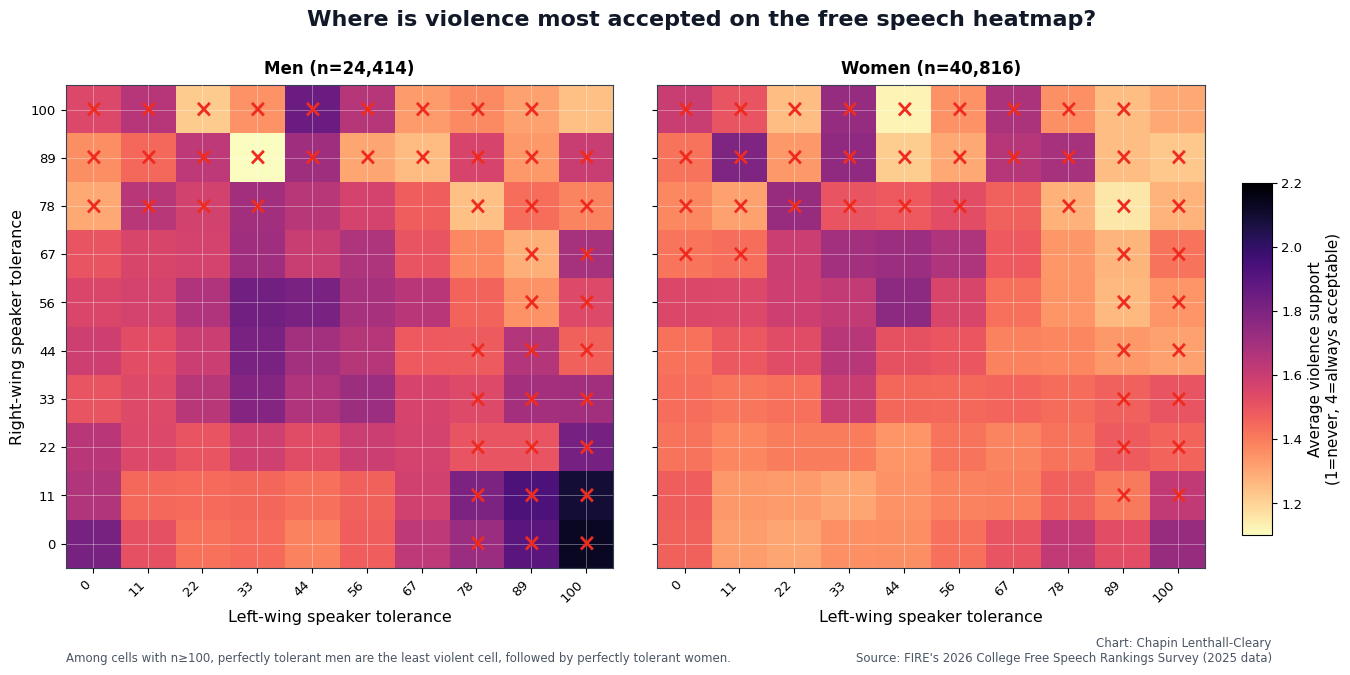

Saved: charts/violense_datapost_plots_2026/11_violence_free_speech_heatmaps_by_gender_2025.png


In [11]:
# 2025 comparison heatmap
violence_cells_2025 = {
    gender_code: build_violence_cells(tolerance_data, 2025, gender_code)
    for gender_code in GENDER_LABELS
}
all_2025_cell_means = pd.concat(
    [table["avg_violence_support"] for table in violence_cells_2025.values()],
    ignore_index=True,
)
violence_2025_vmin = np.floor(all_2025_cell_means.min() * 10) / 10
violence_2025_vmax = np.ceil(all_2025_cell_means.max() * 10) / 10
assert (violence_2025_vmin, violence_2025_vmax) == (1.1, 2.2)

year_data_2025 = tolerance_data[tolerance_data[YEAR_COL].eq(2025)].copy()
x_levels_2025 = sorted(year_data_2025["left_tolerance"].unique())
y_levels_2025 = sorted(year_data_2025["right_tolerance"].unique())
x_index_2025 = {value: position for position, value in enumerate(x_levels_2025)}
y_index_2025 = {value: position for position, value in enumerate(y_levels_2025)}

fig, axes = plt.subplots(1, 2, figsize=(14.8, 7.2), sharex=True, sharey=True)
image = None
for ax, gender_code in zip(axes, GENDER_LABELS):
    matrix = np.full((len(y_levels_2025), len(x_levels_2025)), np.nan)
    counts = np.zeros((len(y_levels_2025), len(x_levels_2025)), dtype=int)
    for row in violence_cells_2025[gender_code].itertuples(index=False):
        x_pos = x_index_2025[row.left_tolerance]
        y_pos = y_index_2025[row.right_tolerance]
        matrix[y_pos, x_pos] = row.avg_violence_support
        counts[y_pos, x_pos] = int(row.n)

    image = ax.imshow(
        matrix,
        origin="lower",
        cmap="magma_r",
        vmin=violence_2025_vmin,
        vmax=violence_2025_vmax,
        aspect="auto",
    )
    for y_pos in range(len(y_levels_2025)):
        for x_pos in range(len(x_levels_2025)):
            if 0 < counts[y_pos, x_pos] < MIN_HEATMAP_CELL_N:
                ax.text(
                    x_pos, y_pos, "×", color="#ef2b20",
                    ha="center", va="center", fontsize=17, fontweight="bold",
                )

    gender_n = int((year_data_2025["heatmap_gender"] == gender_code).sum())
    ax.set_title(
        f"{GENDER_LABELS[gender_code]} (n={gender_n:,})",
        fontsize=12, fontweight="semibold", pad=8,
    )
    ax.set_xlabel("Left-wing speaker tolerance", fontsize=11.5)
    ax.set_xticks(range(len(x_levels_2025)))
    ax.set_xticklabels(
        [f"{value:.0f}" for value in x_levels_2025], rotation=45, ha="right"
    )
    ax.set_yticks(range(len(y_levels_2025)))
    ax.set_yticklabels([f"{value:.0f}" for value in y_levels_2025])
    ax.tick_params(labelsize=9.5)
    ax.grid(color="white", linewidth=0.6, alpha=0.40)
    ax.set_axisbelow(False)
    for spine in ax.spines.values():
        spine.set_color("#374151")
        spine.set_linewidth(0.8)

axes[0].set_ylabel("Right-wing speaker tolerance", fontsize=11.5)
fig.subplots_adjust(left=0.07, right=0.84, bottom=0.19, top=0.86, wspace=0.08)
cbar_ax = fig.add_axes([0.865, 0.235, 0.020, 0.49])
colorbar = fig.colorbar(image, cax=cbar_ax)
colorbar.set_label(
    "Average violence support\n(1=never, 4=always acceptable)", fontsize=11
)
colorbar.ax.tick_params(labelsize=9.5)
add_figure_heading(
    fig,
    "Where is violence most accepted on the free speech heatmap?",
)
fig.text(
    0.07, 0.055,
    "Among cells with n≥100, perfectly tolerant men are the least violent cell, "
    "followed by perfectly tolerant women.",
    ha="left", va="bottom", fontsize=8.5, color=STYLE_MUTED,
)
add_credit(
    fig,
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
    x=0.885, y=0.055,
)
heatmap_2025_path = save_and_show(
    fig, "11_violence_free_speech_heatmaps_by_gender_2025.png"
)
assert len(generated_paths) == 14
assert heatmap_2025_path.exists() and heatmap_2025_path.stat().st_size > 0
